# Why PSBD-TM wins

PSBD-TM masks whole tokens at the input of every attention block (`token_mask` at `before_attention_norm`), and on both the ViT-B/16 and the Swin-S panel it detects backdoored inputs better than PSBD-RD, the dropout on the residual stream that the PSBD paper uses on ConvNets. Step 1 gives the size of the lead. This notebook asks why and answers it by measurement. It asks which part of the placement does the work (the site, the operator or simply how hard it perturbs) and what happens to a trigger's evidence inside the network under each probe.

The reader is assumed to know what a Vision Transformer block is and nothing else about this project. Every term is defined where it first appears, and every figure says what is on its axes, what to look at, what it shows and what it does not show. The notebook reads cached JSON only and runs on a CPU in under a minute. Every number in the prose is computed in the cell above it from the records the experiment wrote. `experiments/why_token_masking_works/README.md` holds the same results as tables with the commands that produced them.

## The map

The walkthrough has 12 steps, each answering 1 question that the previous step raised.

1. The result to explain. How large is PSBD-TM's lead on which attacks and what does it look like in the shift ratios PSU is built from.
2. Whether the measurements are the pipeline's own. 6 sanity gates, and the trigger tokens drawn over an image at every grid.
3. Where a patch trigger is read in ViT. The trigger's tokens hidden from attention by depth.
4. The same question on Swin-S, which has no class token and merges tokens.
5. What PSBD-TM's own random masks do to a triggered prediction. The graded survival curve over the late blocks.
6. What PSBD-RD does instead. Its dropout restricted to the trigger, to the rest or to random positions.
7. Global triggers. How few tokens still carry them.
8. The site and the operator, separated on the cached sweeps. 17 paired contrasts on each architecture.
9. Every operator at every disturbance. The rate ladders.
10. The causal site and operator grid at matched clean disturbance, on the patch models.
11. Why whole tokens. How much of the trigger's own signal survives each probe per block and the attention sink a masked token becomes.
12. The explanations that fail. "It perturbs more", "LayerNorm makes it stronger", "the attention input is special whatever the operator", "whole-token masking is stronger dropout", and 4 more, each with its prediction, measurement and verdict.

Every claim this notebook states as a finding rests on an experiment that changes 1 thing against a control and has a figure. Anything else is labeled **hypothesis** where it appears. When a result cites another paper's argument, the argument is first stated in plain words. A summary figure places every probe on 1 plane and states why each wins or loses. The IDs L2, L18, L20, L22, L24 and L25 refer to entries of the literature memo `docs/why-psbd-works-literature.md`, and "the theory memo" is `docs/why-psbd-works-theory.md`.

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in the library resolves the
# same way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import json
import logging
import warnings

logging.getLogger("lightning.fabric.utilities.seed").setLevel(logging.WARNING)
# torchvision's ToTensor deprecation fires once per dataset load and says nothing
# about the numbers below.
warnings.filterwarnings("ignore", message="The transform `ToTensor", category=UserWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

import scripts.paper._style  # noqa: F401  the figure style every paper figure uses
from scripts.paper._common import word_list

# The shared style selects the Agg backend for the paper build, which keeps every
# figure out of a notebook, so the inline backend comes back after it.
%matplotlib inline


def macro(table, name):
    """1 value of paper/tables/<table>.macros.json, the string headline.tex prints."""
    with open(f"paper/tables/{table}.macros.json") as handle:
        sidecar = json.load(handle)
    value = sidecar["macros"][name]["value"]
    return value


def show_diagram(name, width=None):
    """Embed a TikZ diagram rendered by notebooks/figures/render.py."""
    display(Image(filename=f"notebooks/figures/{name}.png", width=width))

import collections
import re

from matplotlib.patches import FancyBboxPatch, Rectangle

from scripts.paper._common import bootstrap_ci
from scripts.paper._style import ATTACK_COLORS, TEXT_WIDTH, legend_above

EXPERIMENT = Path("results/_experiments/why_token_masking_works")
ARCHITECTURES = ("vit", "swin")
ARCHITECTURE_NAMES = {"vit": "ViT-B/16", "swin": "Swin-S"}
# A TaCT model whose clean source images are misclassified maps the class with
# no trigger, so it is read apart from the trigger-conditional ones everywhere.
TACT_CONDITIONAL_ACCURACY = 0.5


def read_folder(directory):
    skip = {"summary.json", "cache.json", "evidence.json"}
    records = [
        json.load(open(path))
        for path in sorted(Path(directory).glob("*.json"))
        if path.name not in skip
    ]
    return records


def group_of(record):
    if record["attack"] != "tact":
        return record["attack"]
    conditional = record["baseline"]["clean_accuracy"] >= TACT_CONDITIONAL_ACCURACY
    group = "tact" if conditional else "tact_source_mapped"
    return group


def attack_color_of(attack):
    color = ATTACK_COLORS.get(attack.replace("_a2o", "").replace("_a2a", ""), "0.4")
    return color


def mean_and_interval(values):
    low, high = bootstrap_ci(list(values), 10000, 0)
    summary = (float(np.mean(values)), low, high)
    return summary


cache = json.load(open(EXPERIMENT / "sites" / "cache.json"))
evidence = json.load(open(EXPERIMENT / "sites" / "evidence.json"))
gates = {r["folder"]: r for r in read_folder(EXPERIMENT / "gates")}
# The panel is the successful backdoors at the 2-point clean accuracy bar, stored
# in the cache record. A record of a model outside it, measured before the panel
# changed, stays on disk and out of every figure.
PANEL = set(cache["panel"]["vit"]) | set(cache["panel"]["swin"])
site_records = [r for r in read_folder(EXPERIMENT / "sites") if r["folder"] in PANEL]
swin_records = [r for r in read_folder(EXPERIMENT / "swin") if r["folder"] in PANEL]
vit_records = [r for r in read_folder(EXPERIMENT / "vit") if r["folder"] in PANEL]
mechanics_records = [r for r in read_folder(EXPERIMENT / "mechanics") if r["folder"] in PANEL]
first_run = json.load(open(EXPERIMENT / "summary.json"))
counts = {
    "cache models": {a: cache[a]["models"] for a in ARCHITECTURES},
    "gate models": sorted(gates),
    "site grid models": dict(collections.Counter(r["architecture"] for r in site_records)),
    "Swin A to D models": len(swin_records),
    "ViT A to D models (rerun)": len(vit_records),
    "mechanics models": len(mechanics_records),
}
counts

{'cache models': {'vit': 56, 'swin': 65},
 'gate models': ['swin_gtsrb_badnet_a2o_0_05', 'vit_gtsrb_badnet_a2o_0_05'],
 'site grid models': {'swin': 14, 'vit': 15},
 'Swin A to D models': 34,
 'ViT A to D models (rerun)': 29,
 'mechanics models': 29}

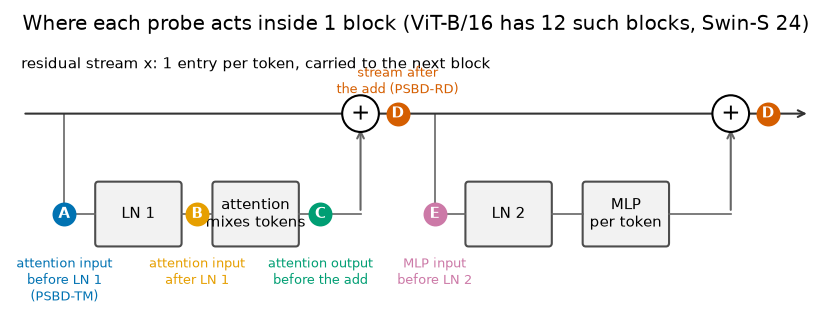

In [2]:
# 1 pre-norm transformer block, drawn left to right, with every site the notebook
# compares marked where its probe acts. The residual stream is the top line. Each
# branch reads the stream, normalizes it, transforms it and adds its output back,
# so a probe on a branch never changes the stream entry itself.
figure, axis = plt.subplots(figsize=(TEXT_WIDTH, 2.3))
axis.set_xlim(0, 13)
axis.set_ylim(0.2, 4.3)
axis.axis("off")
axis.annotate("", xy=(12.9, 3.2), xytext=(0.1, 3.2), arrowprops={"arrowstyle": "->", "color": "0.2"})
axis.text(0.1, 3.9, "residual stream x: 1 entry per token, carried to the next block", fontsize=7)
for label, x in (("LN 1", 2.0), ("attention\nmixes tokens", 3.9), ("LN 2", 8.0), ("MLP\nper token", 9.9)):
    axis.add_patch(FancyBboxPatch((x - 0.65, 1.2), 1.3, 0.9, boxstyle="round,pad=0.05", fc="#f2f2f2", ec="0.3"))
    axis.text(x, 1.65, label, ha="center", va="center", fontsize=7)
for branch_start, add_x, first_box, second_box in ((0.8, 5.6, 2.0, 3.9), (6.8, 11.6, 8.0, 9.9)):
    axis.plot([branch_start, branch_start, first_box - 0.7], [3.2, 1.65, 1.65], color="0.4", linewidth=0.8)
    axis.plot([first_box + 0.7, second_box - 0.7], [1.65, 1.65], color="0.4", linewidth=0.8)
    axis.plot([second_box + 0.7, add_x], [1.65, 1.65], color="0.4", linewidth=0.8)
    axis.annotate("", xy=(add_x, 3.02), xytext=(add_x, 1.65), arrowprops={"arrowstyle": "->", "color": "0.4"})
    axis.text(add_x, 3.2, "+", fontsize=11, ha="center", va="center", bbox={"boxstyle": "circle", "fc": "white"})
sites = [
    (0.8, 1.65, "A", "attention input\nbefore LN 1\n(PSBD-TM)", "#0072B2"),
    (2.95, 1.65, "B", "attention input\nafter LN 1", "#E69F00"),
    (4.95, 1.65, "C", "attention output\nbefore the add", "#009E73"),
    (6.2, 3.2, "D", "stream after\nthe add (PSBD-RD)", "#D55E00"),
    (6.8, 1.65, "E", "MLP input\nbefore LN 2", "#CC79A7"),
    (12.2, 3.2, "D", "", "#D55E00"),
]
for x, y, letter, text, color in sites:
    axis.scatter([x], [y], s=110, color=color, zorder=5)
    axis.text(x, y, letter, ha="center", va="center", color="white", fontsize=7, zorder=6, weight="bold")
    if y < 3:
        axis.text(x, 1.0, text, ha="center", va="top", fontsize=6, color=color)
    else:
        axis.text(x, y + 0.25, text, ha="center", va="bottom", fontsize=6, color=color)
axis.set_title("Where each probe acts inside 1 block (ViT-B/16 has 12 such blocks, Swin-S 24)")
plt.show()

The diagram is 1 block. Both architectures here are pre-norm: every branch reads the residual stream through a LayerNorm (LN), and adds its output back to the stream. The letters are the sites this notebook compares, and the same letters are used in every later figure.

- **A**, `before_attention_norm`, the input of LN 1. A probe here changes what attention reads in this block and nothing else, because the stream entry itself is not touched. PSBD-TM is token masking here.
- **B**, `before_attention`, the same input after LN 1.
- **C**, `before_attention_residual`, the attention branch's output, before it is added to the stream.
- **D**, `post_residual`, the stream itself, right after each of the 2 adds. Every later block sees what a probe here did. PSBD-RD is dropout here.
- **E**, `before_mlp_norm`, the input of LN 2. `before_mlp` is the same input after LN 2.

The operators (`defenses/operators.py`) are these. `token_mask` zeroes whole tokens with probability p, rescales the survivors by 1/(1-p) and never touches ViT's class token. `dropout` zeroes elements. `channel_mask` zeroes whole channels, the same channels for every token of an image. `gaussian` adds noise with standard deviation p times the activation's per-image spread. `rademacher` is the same with random signs. `token_substitute` replaces a token with another token of the same image. A **placement** is a site with an operator, and the probe is attached in every block by `models.positions.plug_dropout`.

**Fractional PSU** is the score every AUROC here reads. For an input $x$ whose unperturbed prediction is class $c$,

$$\phi(x) = 1 - \frac{1}{k}\sum_{i=1}^{k}\frac{P_c(x;p,\theta_i')}{P_c(x;\theta)}$$

| symbol | meaning |
|---|---|
| $P_c(x;\theta)$ | probability of class $c$ on the unperturbed model |
| $P_c(x;p,\theta_i')$ | the same probability on perturbed pass $i$ at rate $p$ |
| $k$ | number of perturbed passes, 3 in every cached sweep |

A low $\phi$ means the prediction survived, which PSBD reads as poisoned. The **shift ratio** of a set of images is the share of (pass, image) pairs whose perturbed prediction differs from the unperturbed one (`defenses.scores.shift_ratio`). The **adaptive rate** is the smallest swept rate whose shift ratio on 2000 held-out clean images reaches 0.8, the rule a defender can deploy. The **matched rate** is the swept rate whose clean shift ratio is closest to 0.6, the device for comparing placements at equal disturbance. **Survival** or "kept" is the share of predictions a probe leaves unchanged, over the triggered images the model sends to the target, or over their clean twins.

## Step 1. The result to explain

The question is how large PSBD-TM's lead is, per model, and what it looks like in the 2 shift ratios PSU is built from. PSU separates when a probe changes clean predictions and leaves triggered ones alone, so the clean and the triggered shift ratio at the rate the adaptive rule picks are the raw material of every AUROC below.

What is measured: per model, the headline AUROC (fractional PSU, 0.25 quantile threshold, at the adaptive rate) of PSBD-TM and PSBD-RD, and the clean and triggered shift ratios at that rate. The source is each model's `results/<folder>/psbd_metrics.json`, read by `experiments/why_token_masking_works/sites.py --cache-only` into `sites/cache.json` (functions `model_row` and `rule_reading`, the same rate and statistic `cli.compare_detectors.psbd_values` reads for the paper). The panel on both architectures is the successful backdoors: the attack clears the 0.85 ASR bar, the model is neither diverged nor source-mapped (a TaCT model that sends its clean source class to the target with no trigger), and its clean accuracy is within 2 points of the benign model of its dataset. On ViT that is the coverage ledger's `successful_2pt` verdict with a cached sweep, 56 models on 2026-09-30, which leaves out the SIG model and 2 WaNet models whose clean accuracy fell further. On Swin the same rule is applied through `scripts.paper._common.swin_coverage`, with the Swin benign models as the reference, 65 models, 63 of them carrying both placements. A failed attack stays out even when that removes the attack. Patch triggers are BadNets, TaCT and Label-Consistent. Every other attack is global.

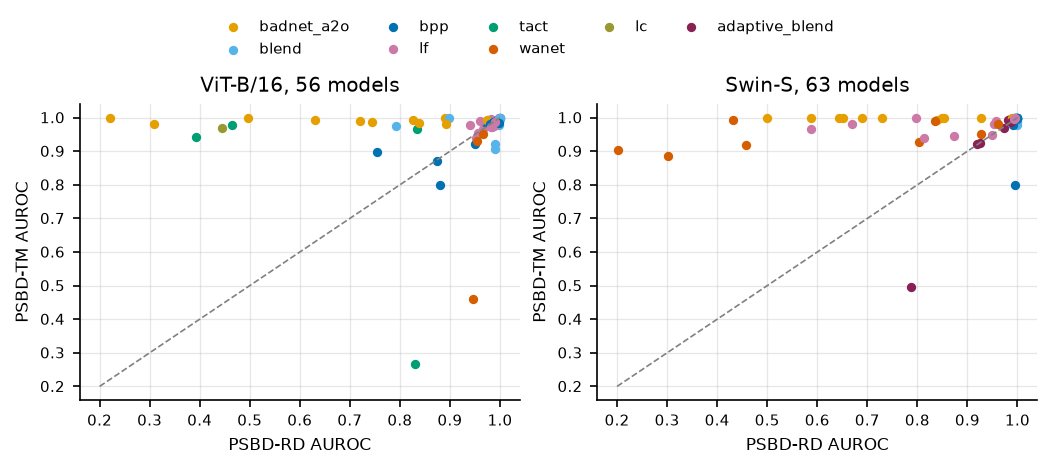

models   rate  clean shift  triggered shift  \
architecture placement trigger                                                
ViT-B/16     PSBD-TM   patch        17  0.529        0.867            0.234   
                       global       39  0.541        0.867            0.079   
             PSBD-RD   patch        17  0.076        0.884            0.695   
                       global       39  0.072        0.871            0.157   
Swin-S       PSBD-TM   patch        12  0.475        0.878            0.009   
                       global       51  0.494        0.877            0.062   
             PSBD-RD   patch        14  0.084        0.857            0.595   
                       global       51  0.071        0.874            0.195   

                                AUROC  
architecture placement trigger         
ViT-B/16     PSBD-TM   patch    0.943  
                       global   0.954  
             PSBD-RD   patch    0.677  
                       global   0.963  
Swin-S       PSBD-TM   patch    0.999  
                       global   0.966  
             PSBD-RD   patch    0.804  
                       global   0.902

In [3]:
TM = "attention_input__token_mask"
# The paper's own headline values, read from the build's macro file, so the prose
# quotes the numbers the paper prints and names the macro that carries each.
PAPER = dict(re.findall(r"\\newcommand\{\\([A-Za-z]+)\}\{([^}]*)\}", open("paper/headline.tex").read()))
RD = "stream__dropout"


def paired_rows(architecture, key_a, key_b, rule):
    rows = []
    for row in cache[architecture]["per_model"]:
        a = row["placements"].get(key_a, {}).get(rule)
        b = row["placements"].get(key_b, {}).get(rule)
        if a is not None and b is not None:
            rows.append((row, a, b))
    return rows


figure, axes = plt.subplots(1, 2, figsize=(TEXT_WIDTH, 2.6), constrained_layout=True)
headline = {}
for axis, architecture in zip(axes, ARCHITECTURES):
    rows = paired_rows(architecture, TM, RD, "adaptive")
    for row, tm, rd in rows:
        axis.scatter(rd["auroc"], tm["auroc"], s=12, color=attack_color_of(row["attack"]), label=row["attack"])
    axis.plot([0.2, 1], [0.2, 1], color="0.5", linewidth=0.8, linestyle="--")
    axis.set_xlabel("PSBD-RD AUROC")
    axis.set_ylabel("PSBD-TM AUROC")
    axis.set_title(f"{ARCHITECTURE_NAMES[architecture]}, {len(rows)} models")
    gaps = [tm["auroc"] - rd["auroc"] for _, tm, rd in rows]
    headline[architecture] = {
        "models": len(rows),
        "tm": np.mean([tm["auroc"] for _, tm, _ in rows]),
        "rd": np.mean([rd["auroc"] for _, _, rd in rows]),
        "gap": mean_and_interval(gaps),
        "tm_wins": sum(g > 0 for g in gaps),
    }
legend_above(figure, list(axes), columns=5)
plt.show()

shift_rows = []
for architecture in ARCHITECTURES:
    for key, name in ((TM, "PSBD-TM"), (RD, "PSBD-RD")):
        for locality in ("local", "global"):
            readings = [
                row["placements"][key]["adaptive"]
                for row in cache[architecture]["per_model"]
                if row["locality"] == locality and row["placements"].get(key, {}).get("adaptive")
            ]
            shift_rows.append({
                "architecture": ARCHITECTURE_NAMES[architecture], "placement": name, "trigger": "patch" if locality == "local" else "global",
                "models": len(readings), "rate": np.mean([r["rate"] for r in readings]),
                "clean shift": np.mean([r["shift_clean"] for r in readings]),
                "triggered shift": np.mean([r["shift_backdoor"] for r in readings]),
                "AUROC": np.mean([r["auroc"] for r in readings]),
            })
shifts = pd.DataFrame(shift_rows).set_index(["architecture", "placement", "trigger"])
shifts.round(3)

In [4]:
display(Markdown(rf"""
Each dot in the figure is 1 model, PSBD-RD's AUROC on the x axis and PSBD-TM's on the y axis, colored by attack, with the diagonal dashed. A dot above the diagonal is a model PSBD-TM detects better. On ViT the means are {headline["vit"]["tm"]:.3f} against {headline["vit"]["rd"]:.3f}, a paired gain of {headline["vit"]["gap"][0]:+.3f} with a 95% bootstrap interval of [{headline["vit"]["gap"][1]:+.3f}, {headline["vit"]["gap"][2]:+.3f}] over {headline["vit"]["models"]} models, and PSBD-TM is ahead on {headline["vit"]["tm_wins"]} of them. On Swin, over the {headline["swin"]["models"]} models carrying both, PSBD-TM is ahead on {headline["swin"]["tm_wins"]}. The paper reports the Swin panel as {PAPER["SwinRecommendedAurocAdaptive"]} for PSBD-TM (`\SwinRecommendedAurocAdaptive`) against {PAPER["SwinPublishedAurocAdaptive"]} for PSBD-RD (`\SwinPublishedAurocAdaptive`), a paired gain of {PAPER["SwinGainRecommendedMinusPublished"]} [{PAPER["SwinGainRecommendedMinusPublishedLow"]}, {PAPER["SwinGainRecommendedMinusPublishedHigh"]}] over {PAPER["SwinGainRecommendedMinusPublishedN"]} models (`\SwinGainRecommendedMinusPublished`). The ViT means above equal the paper's `\HeadlineAurocAdaptive` and `\PublishedAurocAdaptive`, since the statistic, the rate rule and the panel are the paper's own.

The table says where the lead comes from. At the adaptive rate both placements change about {shifts["clean shift"].mean():.2f} of clean predictions, which the rule forces, and they differ in how many triggered predictions they change. On ViT patch triggers PSBD-TM changes {shifts.loc[("ViT-B/16", "PSBD-TM", "patch"), "triggered shift"]:.3f} of triggered predictions against {shifts.loc[("ViT-B/16", "PSBD-RD", "patch"), "triggered shift"]:.3f} for PSBD-RD, and on Swin patch triggers {shifts.loc[("Swin-S", "PSBD-TM", "patch"), "triggered shift"]:.3f} against {shifts.loc[("Swin-S", "PSBD-RD", "patch"), "triggered shift"]:.3f}. On global triggers the 2 are closer ({shifts.loc[("ViT-B/16", "PSBD-TM", "global"), "triggered shift"]:.3f} against {shifts.loc[("ViT-B/16", "PSBD-RD", "global"), "triggered shift"]:.3f} on ViT). So the thing to explain is why whole-token masking at the attention input leaves a patch-triggered prediction alone while it breaks a clean one, and why dropout on the stream does not. The figure does not say which of the site or the operator is responsible, which step 8 separates.
"""))


Each dot in the figure is 1 model, PSBD-RD's AUROC on the x axis and PSBD-TM's on the y axis, colored by attack, with the diagonal dashed. A dot above the diagonal is a model PSBD-TM detects better. On ViT the means are 0.951 against 0.876, a paired gain of +0.075 with a 95% bootstrap interval of [+0.017, +0.136] over 56 models, and PSBD-TM is ahead on 29 of them. On Swin, over the 63 models carrying both, PSBD-TM is ahead on 48. The paper reports the Swin panel as 0.973 for PSBD-TM (`\SwinRecommendedAurocAdaptive`) against 0.881 for PSBD-RD (`\SwinPublishedAurocAdaptive`), a paired gain of +0.096 [+0.051, +0.144] over 63 models (`\SwinGainRecommendedMinusPublished`). The ViT means above equal the paper's `\HeadlineAurocAdaptive` and `\PublishedAurocAdaptive`, since the statistic, the rate rule and the panel are the paper's own.

The table says where the lead comes from. At the adaptive rate both placements change about 0.87 of clean predictions, which the rule forces, and they differ in how many triggered predictions they change. On ViT patch triggers PSBD-TM changes 0.234 of triggered predictions against 0.695 for PSBD-RD, and on Swin patch triggers 0.009 against 0.595. On global triggers the 2 are closer (0.079 against 0.157 on ViT). So the thing to explain is why whole-token masking at the attention input leaves a patch-triggered prediction alone while it breaks a clean one, and why dropout on the stream does not. The figure does not say which of the site or the operator is responsible, which step 8 separates.


## Step 2. Whether the measurements are the pipeline's own

Every later step measures survival with its own forward passes and its own probes. Those numbers are only evidence about PSBD if the model, the splits, the hook sites, the operators, the rates and the pass count are exactly the pipeline's, so 6 gates were run on 1 model per architecture before any full run (`experiments/why_token_masking_works/gates.py`, records under `gates/`). The models are `vit_gtsrb_badnet_a2o_0_05` and `swin_gtsrb_badnet_a2o_0_05`, GTSRB BadNets at 5% poisoning, chosen because GTSRB's 43 classes are the project's default test bed and 5% is the middle rate.

1. Clean accuracy and ASR on the full analysis split (10630 clean and 10578 triggered images) from this code, against `checkpoints/<folder>/args.json` (`metrics.json` is stale for some models, as the audit of 2026-09-29 found) and against the argmax of the cached no-perturbation predictions.
2. PSBD-TM and PSBD-RD at the adaptive rate recomputed on the full validation, clean and triggered splits with this code's plugging, at the cached pass count (k = 3), mask seed and batch size, then scored exactly as `cli.analyze` scores them (`detection_report` on fractional PSU with the clean images paired to the triggered ones). The per-image PSU is compared with the cached PSU and the AUROC with the cached AUROC.
3. The trigger tokens. The pixels the loader's triggered image actually differs from its clean twin in are mapped to tokens at every grid (ViT 14, Swin 56, 28, 14 and 7) and compared with the tokens the helper predicts from the attack's own trigger function. On the unperturbed model the difference between the triggered and the clean residual stream is read at the first block of every stage.
4. No hook or forward override left on the model after use, every module in eval mode, and no model-owned dropout with a nonzero rate. The same check (`swin.assert_pristine`) runs after every measurement of every model in every script.
5. Diverged, source-mapped and unsuccessful models excluded. The ViT panel is the ledger's `successful_2pt` verdict. The Swin panel is the same rule through `swin_coverage`, with the Swin benign models as the reference. SIG is also kept out of every GPU run: `attacks/sig.py` now builds amplitude 0.157 while the ViT SIG checkpoint learned 0.1 (`docs/audits/2026-09-29-experiment-audit.md`), and both SIG models on the 2 panels fail the success bar in any case.
6. Gate 2 repeated with float32 forward passes instead of bfloat16.

Every full run also repeats gate 1 on its own pairs: the unperturbed predictions on the 256 pairs must agree with the cached baseline on at least 98% of images (`tokens.cached_baseline_agreement`), or the run stops.

In [5]:
gate_rows = []
for folder, record in gates.items():
    accuracy = record["gate_1_accuracy"]
    row = {
        "model": folder,
        "clean accuracy (ours / args.json)": f"{accuracy['clean_accuracy_analysis_split']:.4f} / {accuracy['args_json_clean_accuracy']:.4f}",
        "ASR (ours / args.json)": f"{accuracy['asr_analysis_split']:.4f} / {accuracy['args_json_asr']:.4f}",
        "argmax agreement": min(accuracy["argmax_agreement_with_cached_baseline"].values()),
        "hooks left": record["gate_4_hooks_after"]["hooks_after"],
        "modules training": record["gate_4_hooks_after"]["model_state_after"]["modules_in_training_mode"],
        "dropout with p > 0": record["gate_4_hooks_after"]["model_state_after"]["dropout_modules_with_nonzero_rate"],
    }
    for placement, name in (("before_attention_norm_token_mask", "TM"), ("post_residual", "RD")):
        for precision in ("bfloat16", "float32"):
            gate = record[f"gate_2_{placement}_{precision}"]
            row[f"{name} {precision} AUROC ours - cached"] = gate["auroc_ours"] - gate["auroc_cached"]
            row[f"{name} {precision} max |PSU diff| backdoor"] = gate["per_split"]["backdoor"]["max_absolute_difference"]
        row[f"{name} rate, k"] = f"{gate['rate']}, {gate['passes']}"
    gate_rows.append(row)
gate_table = pd.DataFrame(gate_rows).set_index("model").T
display(gate_table)

token_rows = []
for folder, record in gates.items():
    for grid, check in record["gate_3_trigger_tokens"]["per_grid"].items():
        token_rows.append({"model": folder, "grid": int(grid), "predicted tokens": check["predicted_tokens"],
                           "pairs with a change outside the prediction": check["pairs_with_change_outside_predicted"],
                           "predicted tokens the trigger left unchanged (mean)": check["mean_predicted_tokens_unchanged"]})
    for stage, check in record["gate_3_trigger_tokens"]["stream_difference_by_stage"].items():
        token_rows.append({"model": folder, "grid": stage, "predicted tokens": check["predicted_tokens"],
                           "top tokens of the stream difference that are predicted": check["top_difference_tokens_that_are_predicted"],
                           "share of the stream difference on the predicted tokens": check["share_of_difference_on_predicted"]})
pd.DataFrame(token_rows).set_index(["model", "grid"]).round(3)

model,swin_gtsrb_badnet_a2o_0_05,vit_gtsrb_badnet_a2o_0_05
clean accuracy (ours / args.json),0.9653 / 0.9653,0.9862 / 0.9862
ASR (ours / args.json),1.0000 / 1.0000,1.0000 / 1.0000
argmax agreement,1.0,1.0
hooks left,0,0
modules training,0,0
dropout with p > 0,0,0
TM bfloat16 AUROC ours - cached,0.0,0.0
TM bfloat16 max |PSU diff| backdoor,0.0,0.003917
TM float32 AUROC ours - cached,0.0,0.000001
TM float32 max |PSU diff| backdoor,0.006204,0.005175


predicted tokens  \
model                      grid                                
swin_gtsrb_badnet_a2o_0_05 7                               1   
                           14                              4   
                           28                             15   
                           56                             48   
                           block_1_grid_56                48   
                           block_3_grid_28                15   
                           block_5_grid_14                 4   
                           block_23_grid_7                 1   
vit_gtsrb_badnet_a2o_0_05  7                               1   
                           14                              4   
                           block_1_grid_14                 4   

                                            pairs with a change outside the prediction  \
model                      grid                                                          
swin_gtsrb_badnet_a2o_0_05 7                                                       0.0   
                           14                                                      0.0   
                           28                                                      0.0   
                           56                                                      0.0   
                           block_1_grid_56                                         NaN   
                           block_3_grid_28                                         NaN   
                           block_5_grid_14                                         NaN   
                           block_23_grid_7                                         NaN   
vit_gtsrb_badnet_a2o_0_05  7                                                       0.0   
                           14                                                      0.0   
                           block_1_grid_14                                         NaN   

                                            predicted tokens the trigger left unchanged (mean)  \
model                      grid                                                                  
swin_gtsrb_badnet_a2o_0_05 7                                                            0.000    
                           14                                                           0.000    
                           28                                                           0.062    
                           56                                                           0.531    
                           block_1_grid_56                                                NaN    
                           block_3_grid_28                                                NaN    
                           block_5_grid_14                                                NaN    
                           block_23_grid_7                                                NaN    
vit_gtsrb_badnet_a2o_0_05  7                                                            0.000    
                           14                                                           0.000    
                           block_1_grid_14                                                NaN    

                                            top tokens of the stream difference that are predicted  \
model                      grid                                                                      
swin_gtsrb_badnet_a2o_0_05 7                                                              NaN        
                           14                                                             NaN        
                           28                                                             NaN        
                           56                                                             NaN        
                           block_1_grid_56                                               48.0        
                           block_3_grid_28         

In [6]:
display(Markdown(rf"""
Gate 1 passes: this code's clean accuracy and ASR equal `args.json` to 4 decimals on both models and the no-perturbation argmax agrees with the cache on every image. Gate 2 passes: in bfloat16 the per-image PSU of PSBD-RD is identical to the cache on every image of both models, and PSBD-TM differs by at most {max(g["gate_2_before_attention_norm_token_mask_bfloat16"]["per_split"]["backdoor"]["max_absolute_difference"] for g in gates.values()):.4f} on a triggered image, the nondeterminism of bfloat16 matrix products on the GPU, so the AUROCs agree to {max(abs(g[f"gate_2_{p}_bfloat16"]["auroc_ours"] - g[f"gate_2_{p}_bfloat16"]["auroc_cached"]) for g in gates.values() for p in ("before_attention_norm_token_mask", "post_residual")):.1e}. That proves the hook site, the operator, the rate, k, the splits and the pairing are the pipeline's. Gate 6: float32 moves the AUROC by at most {max(abs(g[f"gate_2_{p}_float32"]["auroc_ours"] - g[f"gate_2_{p}_float32"]["auroc_cached"]) for g in gates.values() for p in ("before_attention_norm_token_mask", "post_residual")):.4f}. Per image, float32 changes PSBD-RD's PSU on ViT noticeably (the dropout masks are drawn on tensors of another dtype, so the random stream differs), and the AUROC does not move. Gate 4 passes on both models.

Gate 3 passes at every grid: no pixel the trigger changes falls outside the predicted tokens, on any of 64 pairs. At Swin's finest grid, 56 by 56, some predicted border tokens are touched only by the bilinear spill of the resize and happen not to change on a given image, which is harmless because a mask over an unchanged token is a mask over clean content. The stream check shows the geometry is right in every Swin stage: at the first block of stages 1 to 3 the tokens with the largest triggered minus clean difference are exactly the predicted ones. At the first block of stage 4 the 1 predicted token holds only {gates["swin_gtsrb_badnet_a2o_0_05"]["gate_3_trigger_tokens"]["stream_difference_by_stage"]["block_23_grid_7"]["share_of_difference_on_predicted"]:.3f} of the difference: by then windowed attention has spread the trigger's effect over the whole map, a fact step 4 comes back to.
"""))


Gate 1 passes: this code's clean accuracy and ASR equal `args.json` to 4 decimals on both models and the no-perturbation argmax agrees with the cache on every image. Gate 2 passes: in bfloat16 the per-image PSU of PSBD-RD is identical to the cache on every image of both models, and PSBD-TM differs by at most 0.0039 on a triggered image, the nondeterminism of bfloat16 matrix products on the GPU, so the AUROCs agree to 2.4e-07. That proves the hook site, the operator, the rate, k, the splits and the pairing are the pipeline's. Gate 6: float32 moves the AUROC by at most 0.0003. Per image, float32 changes PSBD-RD's PSU on ViT noticeably (the dropout masks are drawn on tensors of another dtype, so the random stream differs), and the AUROC does not move. Gate 4 passes on both models.

Gate 3 passes at every grid: no pixel the trigger changes falls outside the predicted tokens, on any of 64 pairs. At Swin's finest grid, 56 by 56, some predicted border tokens are touched only by the bilinear spill of the resize and happen not to change on a given image, which is harmless because a mask over an unchanged token is a mask over clean content. The stream check shows the geometry is right in every Swin stage: at the first block of stages 1 to 3 the tokens with the largest triggered minus clean difference are exactly the predicted ones. At the first block of stage 4 the 1 predicted token holds only 0.038 of the difference: by then windowed attention has spread the trigger's effect over the whole map, a fact step 4 comes back to.


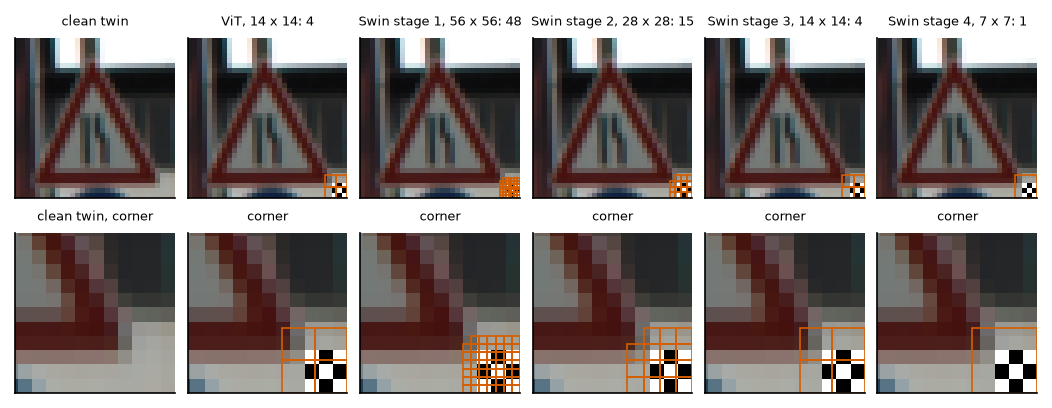

In [7]:
# The trigger's tokens over 1 triggered image, at ViT's 14 x 14 grid and at each
# of Swin's 4 stage grids. The lower row zooms into the corner that holds the
# trigger. A cell is outlined when the trigger changes any pixel in it after the
# model's own resize to 224 (tokens.touched_tokens).
def draw_token_grid(axis, image, positions, grid, title, zoom=None):
    size = len(image)
    axis.imshow(np.array(image, dtype=np.uint8), extent=(0, size, size, 0))
    cell = size / grid
    for position in positions:
        row, column = divmod(position, grid)
        axis.add_patch(Rectangle((column * cell, row * cell), cell, cell, fill=False, edgecolor="#D55E00", linewidth=0.8))
    if zoom is not None:
        axis.set_xlim(size * (1 - zoom), size)
        axis.set_ylim(size, size * (1 - zoom))
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_title(title, fontsize=6)


vit_example = next(r for r in site_records if r["folder"] == "vit_gtsrb_badnet_a2o_0_05")
swin_example = next(r for r in swin_records if r["folder"] == "swin_gtsrb_badnet_a2o_0_05")
panels = [(vit_example, 14, "ViT, 14 x 14")] + [(swin_example, g, f"Swin stage {s}, {g} x {g}") for s, g in ((1, 56), (2, 28), (3, 14), (4, 7))]
figure, axes = plt.subplots(2, 6, figsize=(TEXT_WIDTH, 2.6), constrained_layout=True)
draw_token_grid(axes[0, 0], vit_example["example"]["clean"], [], 14, "clean twin")
draw_token_grid(axes[1, 0], vit_example["example"]["clean"], [], 14, "clean twin, corner", zoom=0.35)
for column, (record, grid, title) in enumerate(panels, start=1):
    positions = record["trigger_positions_by_grid"][str(grid)]
    draw_token_grid(axes[0, column], record["example"]["triggered"], positions, grid, f"{title}: {len(positions)}")
    draw_token_grid(axes[1, column], record["example"]["triggered"], positions, grid, "corner", zoom=0.35)
plt.show()

The upper row is a whole 32 by 32 GTSRB test image with the 3 by 3 BadNets patch in its lower right corner, and the lower row zooms into that corner. The orange cells are the trigger tokens each grid assigns: 4 of ViT's 196 tokens, then 48, 15, 4 and 1 token in Swin's 4 stages, since every patch merging joins 2 by 2 tokens. The patch sits at the corner of a 16 pixel ViT cell after the 7 times resize, which is why it touches 4 tokens and not 1. What the figure does not show is where attention sends the trigger's content afterwards, which the next 2 steps measure.

## Step 3. Where a patch trigger is read in ViT

The question step 1 leaves is why a patch-triggered prediction survives token masking. The hypothesis this project measured first is that the trigger's evidence sits in its own tokens of the residual stream, and that masking a token at the attention input only hides it from the attention read of that block, while the token's stream entry carries the content to the next block. If that is right, hiding the trigger tokens from attention in every block removes the backdoor, hiding them in the early blocks does nothing, and hiding the same number of random tokens does nothing.

What is measured (part A of `measure.py`, rerun on 2026-09-29 into `vit/` with the audit's fixes): on each patch model, the 256 first triggered images of the PSBD analysis split and their clean twins, the trigger tokens are zeroed deterministically at the input of LN 1 (site A) in a span of blocks, and survival is read. The spans are the last m blocks and the first m blocks for m in 1, 2, 4, 8 and 12. The random control zeroes as many non-trigger tokens in all 12 blocks, 3 draws seeded per model. `sites.py` adds 2 more per model: the trigger visible in exactly 1 block (hidden in the other 11) and hidden in exactly 1 block, and the literature memo's L24 test, every token but the trigger's hidden in blocks 9 to 12. The models are the 15 ViT patch models of the panel: 12 BadNets and 3 TaCT models whose clean source images are classified correctly. The 8 source-mapped TaCT models of the first run are no longer in the panel.

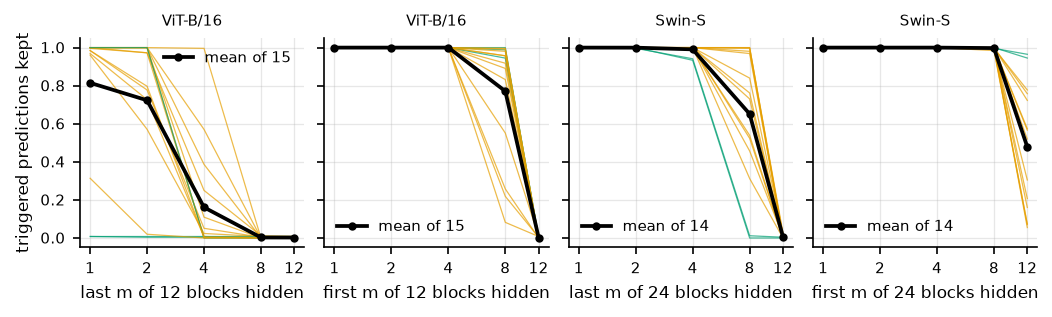

,all 12,blocks 1 to 4,blocks 5 to 8,blocks 9 to 12,"random, all 12","clean kept, all 12"
group,,,,,,
badnet_a2o,0.002,1.0,0.788,0.200,1.000,0.986
tact,0.004,1.0,0.992,0.004,0.998,0.997


In [8]:
def span_curves(records, prefix, spans):
    curves = [
        [r["deterministic_masking"][f"{prefix}_{m}"]["triggered_kept"] for m in spans]
        for r in records
        if "deterministic_masking" in r
    ]
    return curves


SPANS = (1, 2, 4, 8, 12)
vit_patch = [r for r in vit_records if "deterministic_masking" in r and group_of(r) in ("badnet_a2o", "tact", "lc")]
swin_patch = [r for r in swin_records if "deterministic_masking" in r and group_of(r) in ("badnet_a2o", "tact", "lc")]
figure, axes = plt.subplots(1, 4, figsize=(TEXT_WIDTH, 2.0), sharey=True, constrained_layout=True)
for column, (records, total, architecture) in enumerate(((vit_patch, 12, "vit"), (swin_patch, 24, "swin"))):
    for offset, prefix in enumerate(("last", "first")):
        axis = axes[2 * column + offset]
        for record in records:
            curve = [record["deterministic_masking"][f"{prefix}_{m}"]["triggered_kept"] for m in SPANS]
            axis.plot(SPANS, curve, color=attack_color_of(record["attack"]), linewidth=0.6, alpha=0.7)
        curves = span_curves(records, prefix, SPANS)
        if curves:
            axis.plot(SPANS, np.mean(curves, axis=0), color="black", linewidth=1.8, marker="o", markersize=3, label=f"mean of {len(curves)}")
            axis.legend()
        axis.set_xscale("log", base=2)
        axis.set_xticks(SPANS, SPANS)
        axis.set_xlabel(f"{prefix} m of {total} blocks hidden")
        axis.set_title(ARCHITECTURE_NAMES[architecture], fontsize=7)
axes[0].set_ylabel("triggered predictions kept")
plt.show()

vit_a = pd.DataFrame([
    {"model": r["folder"], "group": group_of(r), "all 12": r["deterministic_masking"]["all_12"]["triggered_kept"],
     "blocks 1 to 4": r["deterministic_masking"]["blocks_1_4"]["triggered_kept"],
     "blocks 5 to 8": r["deterministic_masking"]["blocks_5_8"]["triggered_kept"],
     "blocks 9 to 12": r["deterministic_masking"]["blocks_9_12"]["triggered_kept"],
     "random, all 12": r["deterministic_masking"]["random_all_12"]["triggered_kept"],
     "clean kept, all 12": r["deterministic_masking"]["all_12"]["clean_kept"]}
    for r in vit_patch
]).set_index("model")
vit_a_means = vit_a.groupby("group").mean(numeric_only=True)
depth = {r["folder"]: r["depth_profile"] for r in site_records if r["architecture"] == "vit" and "depth_profile" in r}
visible_one = np.array([d["all_but_block"] for d in depth.values()])
hidden_one = np.array([d["only_block"] for d in depth.values()])
only_trigger = pd.DataFrame({f: d["only_trigger_visible_last_4"] for f, d in depth.items()}).T
vit_a_means.round(3)

In [9]:
display(Markdown(rf"""
The first figure pair is ViT. Each thin line is 1 model, colored by attack, and the black line is the mean. Left: the trigger tokens hidden from attention in the last m blocks. Right: hidden in the first m blocks. A curve that stays at 1 as m grows says those blocks never needed to read the trigger. The last 2 panels are the same test on Swin, for step 4.

Hiding the trigger in all 12 blocks keeps {vit_a_means.loc["badnet_a2o", "all 12"]:.3f} of BadNets triggered predictions and {vit_a_means.loc["tact", "all 12"]:.3f} of TaCT ones, while hiding as many random tokens keeps {vit_a_means.loc["badnet_a2o", "random, all 12"]:.3f}, and clean predictions keep {vit_a["clean kept, all 12"].min():.2f} or more throughout. Hiding it in blocks 1 to 4 keeps {vit_a_means.loc["badnet_a2o", "blocks 1 to 4"]:.3f}, so a token hidden from attention early still delivers its content later through its own stream entry, the literature memo's L20. Blocks 5 to 8 matter as well ({vit_a_means.loc["badnet_a2o", "blocks 5 to 8"]:.3f} kept with them hidden) and blocks 9 to 12 most ({vit_a_means.loc["badnet_a2o", "blocks 9 to 12"]:.3f}), so the class token reads a BadNets trigger over the second half of the network and a trigger-conditional TaCT trigger mainly at the end.

The single-block profile over {len(depth)} models sharpens this. With the trigger visible to attention in only 1 block, the mean over models keeps at most {visible_one.mean(axis=0).max():.3f} of triggered predictions (block {int(visible_one.mean(axis=0).argmax()) + 1}), so no single read is enough. With the trigger hidden in only 1 block, the mean keeps at least {hidden_one.mean(axis=0).min():.3f} (block {int(hidden_one.mean(axis=0).argmin()) + 1}), so no single read is necessary. The read is spread over several late blocks, and any 1 of them does part of the work. L24's test hides every other token in blocks 9 to 12 and keeps {only_trigger["triggered_kept"].mean():.3f} of triggered predictions against {only_trigger["clean_kept"].mean():.3f} of clean ones: in the late blocks the class token needs nothing but the trigger. What the figure does not show is how PSBD-TM's random masks, which hide each trigger token in some blocks and not others, fare, which is step 5.
"""))


The first figure pair is ViT. Each thin line is 1 model, colored by attack, and the black line is the mean. Left: the trigger tokens hidden from attention in the last m blocks. Right: hidden in the first m blocks. A curve that stays at 1 as m grows says those blocks never needed to read the trigger. The last 2 panels are the same test on Swin, for step 4.

Hiding the trigger in all 12 blocks keeps 0.002 of BadNets triggered predictions and 0.004 of TaCT ones, while hiding as many random tokens keeps 1.000, and clean predictions keep 0.95 or more throughout. Hiding it in blocks 1 to 4 keeps 1.000, so a token hidden from attention early still delivers its content later through its own stream entry, the literature memo's L20. Blocks 5 to 8 matter as well (0.788 kept with them hidden) and blocks 9 to 12 most (0.200), so the class token reads a BadNets trigger over the second half of the network and a trigger-conditional TaCT trigger mainly at the end.

The single-block profile over 15 models sharpens this. With the trigger visible to attention in only 1 block, the mean over models keeps at most 0.197 of triggered predictions (block 12), so no single read is enough. With the trigger hidden in only 1 block, the mean keeps at least 0.815 (block 12), so no single read is necessary. The read is spread over several late blocks, and any 1 of them does part of the work. L24's test hides every other token in blocks 9 to 12 and keeps 0.901 of triggered predictions against 0.292 of clean ones: in the late blocks the class token needs nothing but the trigger. What the figure does not show is how PSBD-TM's random masks, which hide each trigger token in some blocks and not others, fare, which is step 5.


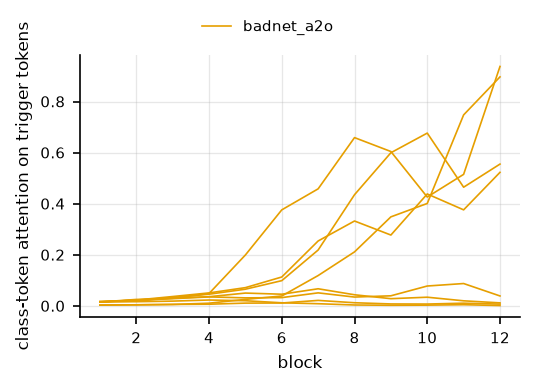

BadNets class-token mass on the trigger: blocks 1 to 4 0.022, blocks 9 to 12 0.287


/lustre/home/pstika/projects/PSBD-ViT/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/lustre/home/pstika/projects/PSBD-ViT/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [10]:
# L20's other half: how much of the class token's attention lands on the trigger
# tokens in each block, BadNets models against the benign references probed with
# the same trigger (results/<folder>/cls_routing.json, written by
# experiments/residual_stream_mechanism/cls_routing.py, copied into evidence.json).
routing = evidence["cls_routing"]
figure, axis = plt.subplots(figsize=(TEXT_WIDTH / 2, 2.2), constrained_layout=True)
for folder, record in routing.items():
    if record["attack"] not in ("badnet_a2o", "benign"):
        continue
    layers = [layer["layer"] for layer in record["layers"]]
    axis.plot(layers, [layer["weight_backdoor"] for layer in record["layers"]],
              color=attack_color_of(record["attack"]) if record["attack"] != "benign" else "0.5",
              linestyle="-" if record["attack"] != "benign" else "--", linewidth=0.8, label=record["attack"])
axis.set_xlabel("block")
axis.set_ylabel("class-token attention on trigger tokens")
legend_above(figure, [axis], columns=2)
plt.show()
benign_late = np.mean([np.mean([layer["weight_backdoor"] for layer in r["layers"][8:]]) for r in routing.values() if r["attack"] == "benign"])
late_mass = np.mean([np.mean([layer["weight_backdoor"] for layer in r["layers"][8:]]) for r in routing.values() if r["attack"] == "badnet_a2o"])
early_mass = np.mean([np.mean([layer["weight_backdoor"] for layer in r["layers"][:4]]) for r in routing.values() if r["attack"] == "badnet_a2o"])
print(f"BadNets class-token mass on the trigger: blocks 1 to 4 {early_mass:.3f}, blocks 9 to 12 {late_mass:.3f}")

In [11]:
display(Markdown(rf"""
Each line is 1 model: the share of the class token's attention, averaged over heads and over triggered images, that lands on the trigger's tokens in each block. BadNets models put {early_mass:.3f} of it there in blocks 1 to 4 and {late_mass:.3f} in blocks 9 to 12, while the dashed benign models, which never learned the trigger, put {benign_late:.3f} there in blocks 9 to 12. This is the route the masking test cut: the class token reads the trigger late and heavily. The figure does not show causation on its own, which the masking test above supplies.
"""))


Each line is 1 model: the share of the class token's attention, averaged over heads and over triggered images, that lands on the trigger's tokens in each block. BadNets models put 0.022 of it there in blocks 1 to 4 and 0.287 in blocks 9 to 12, while the dashed benign models, which never learned the trigger, put nan there in blocks 9 to 12. This is the route the masking test cut: the class token reads the trigger late and heavily. The figure does not show causation on its own, which the masking test above supplies.


## Step 4. The same question on Swin-S

Swin-S differs from ViT in 3 ways that could change the answer. It has no class token: the head reads the mean of the 49 stage-4 tokens. Its attention is restricted to 7 by 7 windows that shift every other block. And its 4 stages merge 2 by 2 tokens at every transition, so a token's own stream entry reaches the head through the merges and the mean pool without any attention. The literature memo's L20 predicted from this that hiding the trigger tokens from attention in every Swin block would leave at least half of the triggered predictions, because the stream entry reaches the pooled head directly.

What is measured (`swin.py`, part A, records under `swin/`): the same protocol with trigger positions resolved per stage (48, 15, 4 and 1 token for a GTSRB BadNets patch), on the 14 Swin patch models of the panel: 12 BadNets and 2 trigger-conditional TaCT. No Swin Label-Consistent model is on the panel. Spans are the last or first m of 24 blocks and the stages. The routes test closes 1 path at a time with the trigger tokens hidden in all 24 blocks: attention only, attention and MLP input, the readout only (the trigger's stage-4 token zeroed before the final LayerNorm), attention and readout, and all 3. Every random control hides as many other tokens per block, 3 draws seeded per model.

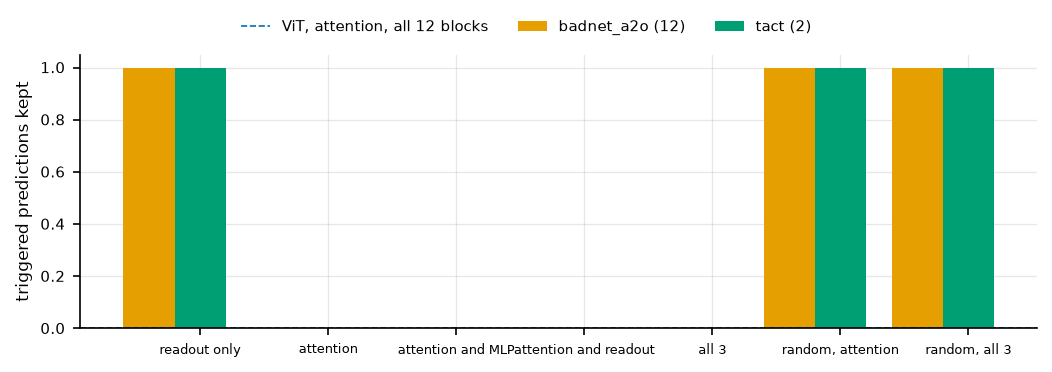

,readout only,attention,attention and MLP,attention and readout,all 3,"random, attention","random, all 3","stage 3, blocks 5 to 13","stage 3, blocks 14 to 22",stage 4,stages 1 and 2,"clean kept, attention"
group,,,,,,,,,,,,
badnet_a2o,1.0,0.003,0.003,0.003,0.003,1.0,1.0,0.541,0.798,1.000,1.0,0.991
tact,1.0,0.002,0.002,0.002,0.002,1.0,1.0,0.994,0.961,0.998,1.0,0.998


In [12]:
ROUTES = (
    ("route_readout_only", "readout only"),
    ("route_attention", "attention"),
    ("route_attention_and_mlp", "attention and MLP"),
    ("route_attention_and_readout", "attention and readout"),
    ("route_everything", "all 3"),
    ("random_attention", "random, attention"),
    ("random_everything", "random, all 3"),
)
route_frame = pd.DataFrame([
    {"model": r["folder"], "group": group_of(r)} | {label: r["deterministic_masking"][key]["triggered_kept"] for key, label in ROUTES}
    | {"stage 3, blocks 5 to 13": r["deterministic_masking"]["stage_3_first_half"]["triggered_kept"],
       "stage 3, blocks 14 to 22": r["deterministic_masking"]["stage_3_second_half"]["triggered_kept"],
       "stage 4": r["deterministic_masking"]["stage_4"]["triggered_kept"],
       "stages 1 and 2": r["deterministic_masking"]["stages_1_2"]["triggered_kept"],
       "clean kept, attention": r["deterministic_masking"]["route_attention"]["clean_kept"]}
    for r in swin_patch
]).set_index("model")
route_means = route_frame.groupby("group").mean(numeric_only=True)

figure, axis = plt.subplots(figsize=(TEXT_WIDTH, 2.1), constrained_layout=True)
labels = [label for _, label in ROUTES]
width = 0.8 / len(route_means)
for offset, (group, row) in enumerate(route_means.iterrows()):
    axis.bar(np.arange(len(labels)) + offset * width, row[labels], width, color=attack_color_of(group), label=f"{group} ({(route_frame['group'] == group).sum()})")
vit_all_hidden = vit_a["all 12"].mean()
axis.axhline(vit_all_hidden, color="#0072B2", linestyle="--", linewidth=0.8, label="ViT, attention, all 12 blocks")
axis.set_xticks(np.arange(len(labels)) + width, labels, fontsize=6)
axis.set_ylabel("triggered predictions kept")
legend_above(figure, [axis], columns=4)
plt.show()
route_means.round(3)

In [13]:
display(Markdown(rf"""
The bars are the Swin routes, grouped by attack, and the dashed line is ViT's value with the trigger hidden from attention in all 12 blocks. L20's prediction for Swin fails. Hiding the trigger tokens from attention in all 24 blocks keeps {route_means.loc["badnet_a2o", "attention"]:.3f} of BadNets triggered predictions, as low as ViT, while clean predictions keep {route_frame["clean kept, attention"].min():.2f} or more. Zeroing the trigger's stage-4 token before the mean pool keeps {route_means.loc["badnet_a2o", "readout only"]:.3f}: the trigger token's own stream entry, merged and pooled, carries essentially none of the backdoor to the head. Closing the MLP route as well changes nothing that attention alone did not already do.

So Swin reads a patch trigger the way ViT does. Windowed attention copies the trigger's evidence out of its own tokens into the tokens around it, and those tokens, not the trigger's, carry it to the pooled head. The depth differs: hiding the trigger in stages 1 and 2 keeps {route_means.loc["badnet_a2o", "stages 1 and 2"]:.3f}, in stage 4 {route_means.loc["badnet_a2o", "stage 4"]:.3f}, and in the 2 halves of stage 3 {route_means.loc["badnet_a2o", "stage 3, blocks 5 to 13"]:.3f} and {route_means.loc["badnet_a2o", "stage 3, blocks 14 to 22"]:.3f}. Swin reads the trigger in stage 3, where it covers 4 tokens of a 14 by 14 map, and by stage 4 the evidence is already spread over the map, which is the stream difference gate 3 found. This is why PSBD-TM works on Swin at all: the property it relies on, a trigger read through attention from a few tokens whose stream entries survive the mask, holds on both architectures.
"""))


The bars are the Swin routes, grouped by attack, and the dashed line is ViT's value with the trigger hidden from attention in all 12 blocks. L20's prediction for Swin fails. Hiding the trigger tokens from attention in all 24 blocks keeps 0.003 of BadNets triggered predictions, as low as ViT, while clean predictions keep 0.98 or more. Zeroing the trigger's stage-4 token before the mean pool keeps 1.000: the trigger token's own stream entry, merged and pooled, carries essentially none of the backdoor to the head. Closing the MLP route as well changes nothing that attention alone did not already do.

So Swin reads a patch trigger the way ViT does. Windowed attention copies the trigger's evidence out of its own tokens into the tokens around it, and those tokens, not the trigger's, carry it to the pooled head. The depth differs: hiding the trigger in stages 1 and 2 keeps 1.000, in stage 4 1.000, and in the 2 halves of stage 3 0.541 and 0.798. Swin reads the trigger in stage 3, where it covers 4 tokens of a 14 by 14 map, and by stage 4 the evidence is already spread over the map, which is the stream difference gate 3 found. This is why PSBD-TM works on Swin at all: the property it relies on, a trigger read through attention from a few tokens whose stream entries survive the mask, holds on both architectures.


## Step 5. What PSBD-TM's own random masks do to a triggered prediction

Steps 3 and 4 hid the trigger deterministically. PSBD-TM hides each token independently with probability p in every block, so a trigger token is hidden in some blocks and visible in others. The question is how survival depends on how often the late reads were hidden.

An earlier version of this README stated that the triggered prediction breaks only when every trigger token is hidden in every late block, an event of probability $p^{4m}$ for $m$ trigger tokens and 4 late blocks. The theory memo (`docs/why-psbd-works-theory.md`, section "Token-mask survival") showed that the frequency of that event is right and the account of breakage is wrong: on the first run the event caused only 7.5% of the broken 4-token predictions. The corrected account is a graded one. Let $J$ be the number of late blocks in which every trigger token is masked. Under independent masks

$$J \sim \mathrm{Bin}(L, p^{m}), \qquad 1 - \mathrm{keep} = \sum_{j=0}^{L}\binom{L}{j}p^{mj}(1-p^{m})^{L-j}(1-s_j)$$

| symbol | meaning |
|---|---|
| $p$ | the masking rate, the model's adaptive PSBD-TM rate |
| $m$ | the number of trigger tokens (4 for most patch triggers, 1 on Tiny) |
| $L$ | the number of late blocks, 4 on ViT (blocks 9 to 12) and 4 on Swin (blocks 21 to 24) |
| $J$ | how many of the $L$ late blocks had every trigger token masked |
| $s_j$ | survival of the triggered prediction given $J = j$ |

What is measured (part B, `RecordingTokenMask`, the library `TokenMask` with its draw stored, held bit for bit to the library operator by `tests/test_why_token_masking_works.py`): PSBD-TM at each model's adaptive rate, 10 passes, masks seeded per model so models at the same rate do not share masks, with $J$ recorded per pass and image. Survival is pooled over (pass, image) pairs for each $j$ and also given per model.

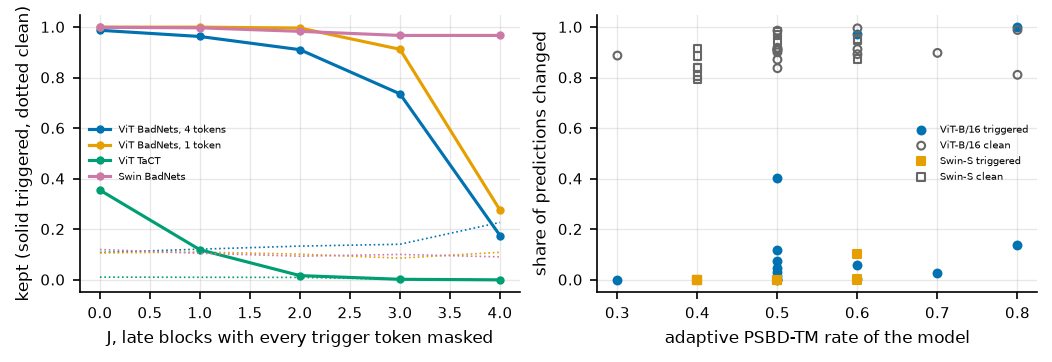

,0,1,2,3,4
"ViT BadNets, 4 tokens",0.988 (14472),0.963 (5887),0.911 (2017),0.736 (587),0.175 (57)
"ViT BadNets, 1 token",1.000 (498),1.000 (1973),0.996 (2839),0.912 (1860),0.276 (500)
ViT TaCT,0.355 (3664),0.119 (2351),0.017 (1127),0.002 (443),0.000 (65)
Swin BadNets,0.999 (6311),0.997 (12809),0.983 (8861),0.967 (2373),0.967 (366)


In [14]:
def pooled_by_count(records, part, statistic, split="triggered"):
    counts = collections.defaultdict(lambda: [0, 0])
    for record in records:
        for value, (kept, total) in record[part][split][statistic].items():
            counts[int(value)][0] += kept
            counts[int(value)][1] += total
    pooled = {j: (kept / total, total) for j, (kept, total) in sorted(counts.items()) if total}
    return pooled


b_sets = {
    "ViT BadNets, 4 tokens": [r for r in vit_records if "stochastic_token_mask" in r and group_of(r) == "badnet_a2o" and len(r["trigger_positions"]) == 4],
    "ViT BadNets, 1 token": [r for r in vit_records if "stochastic_token_mask" in r and group_of(r) == "badnet_a2o" and len(r["trigger_positions"]) == 1],
    "ViT TaCT": [r for r in vit_records if "stochastic_token_mask" in r and group_of(r) == "tact"],
    "Swin BadNets": [r for r in swin_records if "stochastic_token_mask" in r and group_of(r) == "badnet_a2o"],
    "Swin LC and TaCT": [r for r in swin_records if "stochastic_token_mask" in r and group_of(r) in ("lc", "tact")],
}
figure, axes = plt.subplots(1, 2, figsize=(TEXT_WIDTH, 2.3), constrained_layout=True)
s_j = {}
for label, records in b_sets.items():
    if not records:
        continue
    statistic = "late_all"
    triggered = pooled_by_count(records, "stochastic_token_mask", statistic)
    clean = pooled_by_count(records, "stochastic_token_mask", statistic, "clean")
    s_j[label] = triggered
    axes[0].plot(list(triggered), [v for v, _ in triggered.values()], marker="o", markersize=3, label=label)
    axes[0].plot(list(clean), [v for v, _ in clean.values()], linestyle=":", color=axes[0].lines[-1].get_color(), linewidth=0.8)
axes[0].set_xlabel("J, late blocks with every trigger token masked")
axes[0].set_ylabel("kept (solid triggered, dotted clean)")
axes[0].legend(fontsize=5)

per_model = pd.DataFrame([
    {"model": r["folder"], "architecture": r["architecture"] if "architecture" in r else "vit", "rate": r["tm_rate"],
     "triggered kept": r["stochastic_token_mask"]["overall"]["triggered_kept"], "clean kept": r["stochastic_token_mask"]["overall"]["clean_kept"],
     "full late mask events": r["stochastic_token_mask"]["triggered"]["late_all"].get("4", [0, 0])[1],
     "pairs": sum(t for _, t in r["stochastic_token_mask"]["triggered"]["late_all"].values())}
    for r in vit_records + swin_records if "stochastic_token_mask" in r and group_of(r) in ("badnet_a2o", "tact", "lc")
]).set_index("model")
for architecture, marker in (("vit", "o"), ("swin", "s")):
    rows = per_model[per_model["architecture"] == architecture]
    axes[1].scatter(rows["rate"], 1 - rows["triggered kept"], marker=marker, s=14, label=f"{ARCHITECTURE_NAMES[architecture]} triggered")
    axes[1].scatter(rows["rate"], 1 - rows["clean kept"], marker=marker, s=14, facecolors="none", edgecolors="0.4", label=f"{ARCHITECTURE_NAMES[architecture]} clean")
axes[1].set_xlabel("adaptive PSBD-TM rate of the model")
axes[1].set_ylabel("share of predictions changed")
axes[1].legend(fontsize=5)
plt.show()

broken = {}
for label, records in b_sets.items():
    counts = collections.Counter()
    for record in records:
        for value, (kept, total) in record["stochastic_token_mask"]["triggered"]["late_all"].items():
            counts[int(value)] += total - kept
    broken[label] = {j: counts[j] / max(sum(counts.values()), 1) for j in sorted(counts)}
pd.DataFrame({label: {j: f"{v:.3f} ({n})" for j, (v, n) in curve.items()} for label, curve in s_j.items()}).T

In [15]:
display(Markdown(rf"""
Left: pooled survival for each value of $J$, triggered solid and clean dotted, with the (pass, image) counts in the table above. Right: every model's share of changed triggered (filled) and clean (open) predictions against its own adaptive rate.

The curve is graded. On the ViT 4-token BadNets models triggered survival is {s_j.get("ViT BadNets, 4 tokens", {}).get(0, (float("nan"), 0))[0]:.3f} with no late block fully masked and falls with every additional one, to {s_j.get("ViT BadNets, 4 tokens", {}).get(3, (float("nan"), 0))[0]:.3f} at $J = 3$ and {s_j.get("ViT BadNets, 4 tokens", {}).get(4, (float("nan"), 0))[0]:.3f} at $J = 4$ (a count of {s_j.get("ViT BadNets, 4 tokens", {}).get(4, (0, 0))[1]} pairs). The prediction weakens with every partly hidden late read rather than breaking only when all are hidden. The broken 4-token predictions split over $J$ = 0 to 4 as {", ".join(f"{v:.2f}" for v in broken.get("ViT BadNets, 4 tokens", {}).values())}, so the full event accounts for a small share of the breakage, as the theory memo found on the first run. Clean survival does not fall with $J$ (it stays between {min(v for v, _ in pooled_by_count(b_sets["ViT BadNets, 4 tokens"], "stochastic_token_mask", "late_all", "clean").values()):.3f} and {max(v for v, _ in pooled_by_count(b_sets["ViT BadNets, 4 tokens"], "stochastic_token_mask", "late_all", "clean").values()):.3f}, the highest value on the few passes with $J = 4$), the control that says the trigger positions do not matter to a clean prediction. How often the full event happens depends almost entirely on the rate, since $p^{{16}}$ is 4e-9 at p 0.3 and 0.03 at p 0.8, so any pooled "share of full events" is set by the few models at high rates and is not a property of 4-token triggers. The right panel shows why this matters little for detection: at their own adaptive rates the models change fewer triggered than clean predictions.
"""))


Left: pooled survival for each value of $J$, triggered solid and clean dotted, with the (pass, image) counts in the table above. Right: every model's share of changed triggered (filled) and clean (open) predictions against its own adaptive rate.

The curve is graded. On the ViT 4-token BadNets models triggered survival is 0.988 with no late block fully masked and falls with every additional one, to 0.736 at $J = 3$ and 0.175 at $J = 4$ (a count of 57 pairs). The prediction weakens with every partly hidden late read rather than breaking only when all are hidden. The broken 4-token predictions split over $J$ = 0 to 4 as 0.23, 0.28, 0.23, 0.20, 0.06, so the full event accounts for a small share of the breakage, as the theory memo found on the first run. Clean survival does not fall with $J$ (it stays between 0.108 and 0.227, the highest value on the few passes with $J = 4$), the control that says the trigger positions do not matter to a clean prediction. How often the full event happens depends almost entirely on the rate, since $p^{16}$ is 4e-9 at p 0.3 and 0.03 at p 0.8, so any pooled "share of full events" is set by the few models at high rates and is not a property of 4-token triggers. The right panel shows why this matters little for detection: at their own adaptive rates the models change fewer triggered than clean predictions.


## Step 6. What PSBD-RD does instead

The first run's account of PSBD-RD was that dropout on the stream corrupts the trigger tokens' stored content in every block, so dropout on the trigger's positions alone breaks as many triggered predictions as dropout everywhere. The theory memo showed that this holds for the mean over models only. Per model the 2 differ by 0.223 on average, and on 8 of 12 models dropout everywhere keeps more triggered predictions than either half does alone, which a first-order account forbids: it means dropout on the content positions also lowers the logit of the class that competes with the target.

What is measured (part C of `measure.py` on ViT and of `swin.py` on Swin): PSBD-RD at each model's adaptive rate, 10 passes, on all tokens as the library does, on the trigger positions only, on every other position (class token included on ViT), and on as many random positions per block (3 draws, seeded per model). The dropout itself is the library `nn.Dropout`, restricted by `PositionDropout` on ViT and by `tokens.PositionRestricted` per block on Swin.

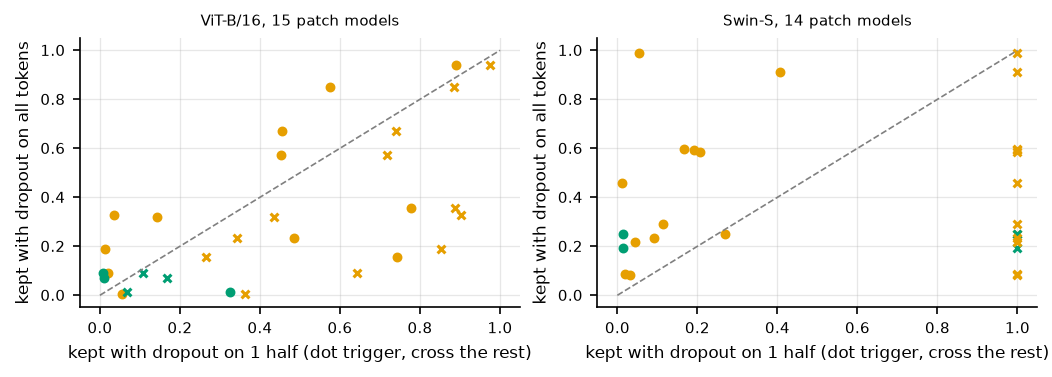

,all tokens,trigger only,all but trigger,random,"clean, all tokens",|all - trigger only|,above both halves,group
architecture,,,,,,,,
swin,0.409,0.117,1.000,1.0,0.100,0.295,13,14
vit,0.326,0.332,0.556,1.0,0.098,0.210,10,15


In [16]:
c_rows = []
for record in vit_records + swin_records:
    if "residual_dropout" not in record or group_of(record) not in ("badnet_a2o", "tact", "lc"):
        continue
    dropout = record["residual_dropout"]
    c_rows.append({
        "model": record["folder"], "architecture": record.get("architecture", "vit"), "group": group_of(record), "rate": dropout["rate"],
        "all tokens": dropout["all_tokens"]["triggered_kept"], "trigger only": dropout["trigger_only"]["triggered_kept"],
        "all but trigger": dropout["all_but_trigger"]["triggered_kept"], "random": dropout["random_same_count"]["triggered_kept"],
        "clean, all tokens": dropout["all_tokens"]["clean_kept"],
    })
c_frame = pd.DataFrame(c_rows).set_index("model")
c_frame["above both halves"] = c_frame["all tokens"] > c_frame[["trigger only", "all but trigger"]].min(axis=1)
c_frame["|all - trigger only|"] = (c_frame["all tokens"] - c_frame["trigger only"]).abs()

figure, axes = plt.subplots(1, 2, figsize=(TEXT_WIDTH, 2.4), constrained_layout=True)
for axis, architecture in zip(axes, ARCHITECTURES):
    rows = c_frame[c_frame["architecture"] == architecture]
    for name, row in rows.iterrows():
        axis.scatter(row["trigger only"], row["all tokens"], color=attack_color_of(row["group"]), s=14)
        axis.scatter(row["all but trigger"], row["all tokens"], color=attack_color_of(row["group"]), s=14, marker="x")
    axis.plot([0, 1], [0, 1], color="0.5", linestyle="--", linewidth=0.8)
    axis.set_xlabel("kept with dropout on 1 half (dot trigger, cross the rest)")
    axis.set_ylabel("kept with dropout on all tokens")
    axis.set_title(f"{ARCHITECTURE_NAMES[architecture]}, {len(rows)} patch models", fontsize=7)
plt.show()
c_summary = c_frame.groupby("architecture").agg({"all tokens": "mean", "trigger only": "mean", "all but trigger": "mean", "random": "mean",
                                                   "clean, all tokens": "mean", "|all - trigger only|": "mean", "above both halves": "sum", "group": "count"})
c_summary.round(3)

In [17]:
display(Markdown(rf"""
Each model appears twice, once as a dot (dropout on the trigger only, x axis) and once as a cross (dropout on every other position), with survival under dropout on all tokens on the y axis. A point on the diagonal means that half alone does all the damage. On ViT the means are {c_summary.loc["vit", "all tokens"]:.3f} kept under the library's dropout, {c_summary.loc["vit", "trigger only"]:.3f} with the trigger only, {c_summary.loc["vit", "all but trigger"]:.3f} with the rest and {c_summary.loc["vit", "random"]:.3f} with random positions, against {c_summary.loc["vit", "clean, all tokens"]:.3f} of clean predictions kept. The mean agreement between "all" and "trigger only" hides a per-model gap of {c_summary.loc["vit", "|all - trigger only|"]:.3f} on average, and on {int(c_summary.loc["vit", "above both halves"])} of {int(c_summary.loc["vit", "group"])} models dropout everywhere keeps more than the weaker half. On Swin the library's dropout keeps {c_summary.loc["swin", "all tokens"]:.3f} of triggered predictions, trigger only {c_summary.loc["swin", "trigger only"]:.3f}, the rest {c_summary.loc["swin", "all but trigger"]:.3f}, random {c_summary.loc["swin", "random"]:.3f}.

The finding, isolated by the restriction with random positions as the control: dropout on the trigger's positions breaks triggered predictions and dropout on as many random positions does not, so the trigger's positions are where PSBD-RD hurts a triggered prediction. The halves do not add, and "all tokens" can keep more than either half. **Hypothesis**, from the theory memo and not measured here: dropout on the content positions also weakens the clean evidence for the class competing with the target, which keeps the target ahead. Testing it needs the competing class's logit per pass, which these records do not store. What this step does not show is how much of the trigger's signal each probe leaves in each block, which step 11 measures directly.
"""))


Each model appears twice, once as a dot (dropout on the trigger only, x axis) and once as a cross (dropout on every other position), with survival under dropout on all tokens on the y axis. A point on the diagonal means that half alone does all the damage. On ViT the means are 0.326 kept under the library's dropout, 0.332 with the trigger only, 0.556 with the rest and 1.000 with random positions, against 0.098 of clean predictions kept. The mean agreement between "all" and "trigger only" hides a per-model gap of 0.210 on average, and on 10 of 15 models dropout everywhere keeps more than the weaker half. On Swin the library's dropout keeps 0.409 of triggered predictions, trigger only 0.117, the rest 1.000, random 1.000.

The finding, isolated by the restriction with random positions as the control: dropout on the trigger's positions breaks triggered predictions and dropout on as many random positions does not, so the trigger's positions are where PSBD-RD hurts a triggered prediction. The halves do not add, and "all tokens" can keep more than either half. **Hypothesis**, from the theory memo and not measured here: dropout on the content positions also weakens the clean evidence for the class competing with the target, which keeps the target ahead. Testing it needs the competing class's logit per pass, which these records do not store. What this step does not show is how much of the trigger's signal each probe leaves in each block, which step 11 measures directly.


## Step 7. Global triggers

A global trigger (Blend, LF, BPP or WaNet) is present in every token, so no small set of tokens carries it. The question is whether it stays legible from a random subset of tokens while clean content does not. That is what would make a triggered prediction survive token masking without any routing argument.

What is measured (part D): a fixed random subset of tokens is kept visible and every other token is hidden at the attention input of all 12 ViT blocks, at visible fractions f of 0.6, 0.3 and 0.1. On Swin the subset is drawn over the 7 by 7 cells that nest into every stage, and a hidden cell is hidden at both branch inputs of all 24 blocks and at the readout, since Swin's MLP, merges and mean pool would otherwise still carry its content. 20 subsets per model and fraction, drawn per model (the audit found the first run drawing the same 3 subsets for every model). 1 model per attack and dataset, the 5% model where it cleared. Retention is read as **excess retention**: (triggered ASR minus the share of clean images sent to the target) at f, over the same quantity at f = 1, because a heavily masked model collapses onto 1 default class that is often the target, and raw ASR retention would then read that collapse as survival.

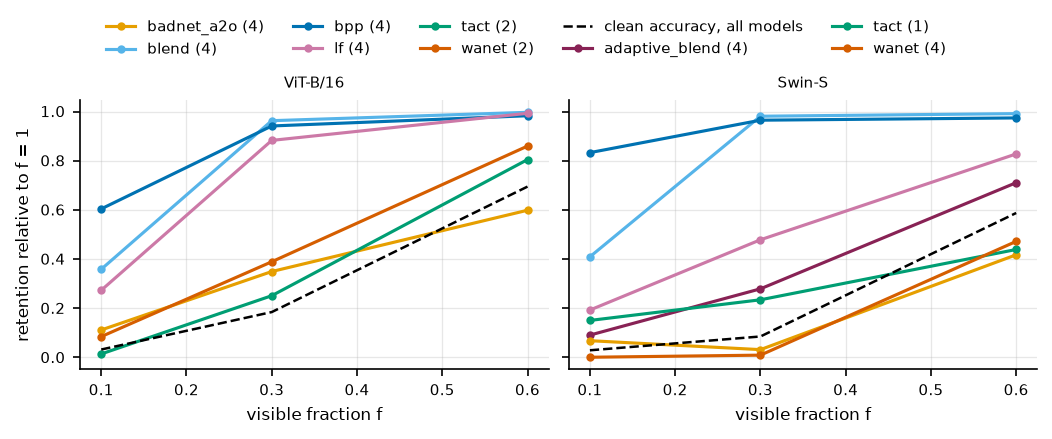

clean retention               excess retention  \
f                                       0.1    0.3    0.6              0.1   
architecture group                                                           
swin         adaptive_blend           0.029  0.111  0.581            0.091   
             badnet_a2o               0.015  0.039  0.514            0.068   
             blend                    0.042  0.092  0.652            0.409   
             bpp                      0.058  0.175  0.729            0.833   
             lf                       0.039  0.110  0.565            0.193   
             tact                     0.000  0.002  0.720            0.151   
             wanet                    0.000  0.005  0.451            0.001   
vit          badnet_a2o               0.018  0.187  0.582            0.112   
             blend                    0.031  0.240  0.715            0.359   
             bpp                      0.045  0.193  0.752            0.604   
             lf                       0.041  0.200  0.708            0.273   
             tact                     0.000  0.040  0.723            0.014   
             wanet                    0.052  0.166  0.709            0.085   

                                           
f                              0.3    0.6  
architecture group                         
swin         adaptive_blend  0.279  0.711  
             badnet_a2o      0.032  0.417  
             blend           0.981  0.991  
             bpp             0.965  0.974  
             lf              0.479  0.828  
             tact            0.235  0.439  
             wanet           0.009  0.472  
vit          badnet_a2o      0.349  0.599  
             blend           0.963  0.997  
             bpp             0.941  0.983  
             lf              0.883  0.993  
             tact            0.251  0.804  
             wanet           0.389  0.859

In [18]:
def excess(subsets, fraction):
    reading, reference = subsets[fraction]["mean"], subsets["1.0"]["mean"]
    denominator = reference["triggered_asr"] - reference["clean_on_target"]
    value = (reading["triggered_asr"] - reading["clean_on_target"]) / denominator if denominator > 0 else np.nan
    return value


d_rows = []
for record in vit_records + swin_records:
    if "visible_subsets" not in record:
        continue
    subsets = record["visible_subsets"]
    for fraction in ("0.6", "0.3", "0.1"):
        d_rows.append({"model": record["folder"], "architecture": record.get("architecture", "vit"), "group": group_of(record), "f": float(fraction),
                       "excess retention": excess(subsets, fraction),
                       "clean retention": subsets[fraction]["mean"]["clean_accuracy_retention"],
                       "draws": len(subsets[fraction]["draws"])})
d_frame = pd.DataFrame(d_rows)
figure, axes = plt.subplots(1, 2, figsize=(TEXT_WIDTH, 2.4), sharey=True, constrained_layout=True)
for axis, architecture in zip(axes, ARCHITECTURES):
    rows = d_frame[d_frame["architecture"] == architecture]
    for group, group_rows in rows.groupby("group"):
        means = group_rows.groupby("f")[["excess retention", "clean retention"]].mean()
        axis.plot(means.index, means["excess retention"], marker="o", markersize=3, color=attack_color_of(group), label=f"{group} ({group_rows['model'].nunique()})")
    clean_means = rows.groupby("f")["clean retention"].mean()
    axis.plot(clean_means.index, clean_means.values, color="black", linestyle="--", linewidth=1.2, label="clean accuracy, all models")
    axis.set_xlabel("visible fraction f")
    axis.set_title(ARCHITECTURE_NAMES[architecture], fontsize=7)
axes[0].set_ylabel("retention relative to f = 1")
legend_above(figure, list(axes), columns=5)
plt.show()
d_table = d_frame.pivot_table(index=["architecture", "group"], columns="f", values=["excess retention", "clean retention"]).round(3)
d_table

In [19]:
display(Markdown(rf"""
Each colored line is the mean over that attack's models of its excess retention, and the dashed black line is clean accuracy retention over all models, at the visible fraction on the x axis. A trigger line above the dashed line means the trigger stays legible from fewer tokens than clean content. On ViT the Blend, BPP and LF models keep most of their excess ASR at 30% visible tokens while clean accuracy keeps {d_frame[(d_frame.architecture == "vit") & (d_frame.f == 0.3)]["clean retention"].mean():.2f} of its level (the literature memo's L23). WaNet keeps {d_table.loc[("vit", "wanet"), ("excess retention", 0.3)]:.3f} at f 0.3 on its 2 panel models, between the other global triggers and clean content. On Swin the Blend and BPP models stay legible, the LF models less so and WaNet falls with the clean content ({d_table.loc[("swin", "wanet"), ("excess retention", 0.3)]:.3f} at f 0.3), so L23's prediction for Swin, at least 0.5 if windowed processing made WaNet locally legible, fails. The table gives every value. What this step does not decide is whether it is the attention input specifically that makes the global triggers survive, which the operator comparisons of steps 8 to 10 test.
"""))


Each colored line is the mean over that attack's models of its excess retention, and the dashed black line is clean accuracy retention over all models, at the visible fraction on the x axis. A trigger line above the dashed line means the trigger stays legible from fewer tokens than clean content. On ViT the Blend, BPP and LF models keep most of their excess ASR at 30% visible tokens while clean accuracy keeps 0.18 of its level (the literature memo's L23). WaNet keeps 0.389 at f 0.3 on its 2 panel models, between the other global triggers and clean content. On Swin the Blend and BPP models stay legible, the LF models less so and WaNet falls with the clean content (0.009 at f 0.3), so L23's prediction for Swin, at least 0.5 if windowed processing made WaNet locally legible, fails. The table gives every value. What this step does not decide is whether it is the attention input specifically that makes the global triggers survive, which the operator comparisons of steps 8 to 10 test.


### The failing WaNet model

1 WaNet model is where PSBD-TM fails outright: `vit_cifar10_wanet_0_1` reads 0.459, below chance, while its SAM-trained twins read 0.852 to 0.957. 2 questions follow, both from `docs/simple-experiments-plan.md`.

X1 asks whether the triggered predictions that PSBD-TM breaks on this model fall back to the image's true class. WaNet trains with "noise mode", in which 20% of the poisoned images carry a random warp and keep their true label, so the model learns to answer the true class when the warp is not exactly right. If masking spoils the warp, the prediction should return to the true class. This was measured on CPU from the cached per-pass predictions by the coordinating agent, not by this experiment: at the adaptive rate the model changes 0.729 of triggered passes, and only 0.158 of those land on the true class, against a prediction of at least 0.7. The 2 Tiny WaNet models change only 0.005 and 0.037 of triggered passes. The noise-mode account is therefore not supported on the failing model, and that result has no figure here because its record is not in this experiment.

X2 asks whether 0.459 is an accident of 1 checkpoint or a property of the recipe. The same recipe was trained twice more with other seeds (`_seed_1`, `_seed_2`, ASR 0.885 and 0.889) and never swept. They are swept here with PSBD-TM and PSBD-RD on the pipeline's own ladders (`cli.sweep` followed by `cli.analyze`), and the cell below compares the 3 seeds. The seed is the only thing that changes.

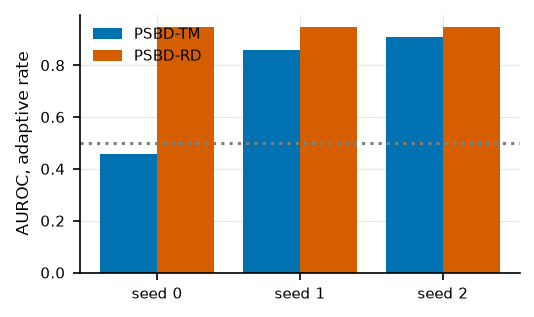

,folder,PSBD-TM,PSBD-RD
seed,,,
0,vit_cifar10_wanet_0_1,0.459,0.947
1,vit_cifar10_wanet_0_1_seed_1,0.858,0.949
2,vit_cifar10_wanet_0_1_seed_2,0.908,0.948


In [20]:
wanet_rows = []
for seed, folder in (("0", "vit_cifar10_wanet_0_1"), ("1", "vit_cifar10_wanet_0_1_seed_1"), ("2", "vit_cifar10_wanet_0_1_seed_2")):
    path = Path("results") / folder / "psbd_metrics.json"
    if not path.exists():
        wanet_rows.append({"seed": seed, "folder": folder, "PSBD-TM": np.nan, "PSBD-RD": np.nan})
        continue
    placements = json.load(open(path))["placements"]
    row = {"seed": seed, "folder": folder}
    for name, placement in (("PSBD-TM", "before_attention_norm_token_mask"), ("PSBD-RD", "post_residual")):
        block = placements.get(placement, {})
        rate = block.get("adaptive_rate")
        entry = next((r for r in block.get("rates", []) if r["rate"] == rate), None)
        row[name] = entry["detection_psu_ratio"]["q0.25"]["auroc"] if entry else np.nan
    wanet_rows.append(row)
wanet = pd.DataFrame(wanet_rows).set_index("seed")
figure, axis = plt.subplots(figsize=(TEXT_WIDTH / 2, 2.0), constrained_layout=True)
positions = np.arange(len(wanet))
axis.bar(positions - 0.2, wanet["PSBD-TM"], 0.4, label="PSBD-TM", color="#0072B2")
axis.bar(positions + 0.2, wanet["PSBD-RD"], 0.4, label="PSBD-RD", color="#D55E00")
axis.axhline(0.5, color="0.5", linestyle=":")
axis.set_xticks(positions, [f"seed {s}" for s in wanet.index])
axis.set_ylabel("AUROC, adaptive rate")
axis.legend()
plt.show()
wanet.round(3)

In [21]:
display(Markdown(rf"""
Each pair of bars is 1 seed of the same CIFAR-10 WaNet 10% recipe, PSBD-TM in blue and PSBD-RD in orange, with chance dotted. A missing bar means that seed's sweep had not run when the notebook was executed. {"Seeds 1 and 2 read PSBD-TM " + ", ".join(f"{v:.3f}" for v in wanet.loc[["1", "2"], "PSBD-TM"]) + ", so the failure of seed 0 " + ("recurs, a property of the recipe." if (wanet.loc[["1", "2"], "PSBD-TM"] < 0.6).all() else "does not recur on every seed, so 0.459 is at least partly an accident of 1 checkpoint.") if wanet.loc[["1", "2"], "PSBD-TM"].notna().all() else "The replicate sweeps are listed under the run status in the README and the question stays open until they land."}
"""))


Each pair of bars is 1 seed of the same CIFAR-10 WaNet 10% recipe, PSBD-TM in blue and PSBD-RD in orange, with chance dotted. A missing bar means that seed's sweep had not run when the notebook was executed. Seeds 1 and 2 read PSBD-TM 0.858, 0.908, so the failure of seed 0 does not recur on every seed, so 0.459 is at least partly an accident of 1 checkpoint.


## Step 8. The site and the operator, separated on the cached sweeps

PSBD-TM combines a site (the attention input, before its LayerNorm) and an operator (whole-token masking). Each of them could be the reason it wins, and so could the plain fact that it perturbs harder at its adaptive rate. Each explanation predicts a different pattern when 1 factor changes and the other stays fixed:

| explanation | prediction when 1 factor changes |
|---|---|
| the stream stays untouched at a branch input | token masking on the stream (site D) loses to site A, and a branch output (site C) ties with site A |
| the operator removes whole tokens | at site A, dropout, channel masking and Gaussian noise lose to token masking, and token masking wins at other sites too |
| a LayerNorm absorbs the probe | additive noise before the norm loses to the same noise after it, and token masking is unaffected by the norm |
| attention has not yet mixed the tokens | token masking at the MLP input (site E) loses to site A, since attention has already copied the trigger into other tokens |
| it just perturbs more | the gaps vanish at the matched clean shift of 0.6 |

What is measured: for each pair of placements, the per-model AUROC difference over the models carrying both, at the adaptive rule and at the matched rule, with a 95% bootstrap interval (10000 resamples, `scripts.paper._common.bootstrap_ci`), plus both placements' clean and triggered shift ratios (`sites.contrast_table`). ViT has the full grid of 9 positions by 4 operators on 36 of the 56 models, and every contrast uses only the models carrying both of its placements. Swin has a smaller cached grid, so some contrasts have no Swin row.

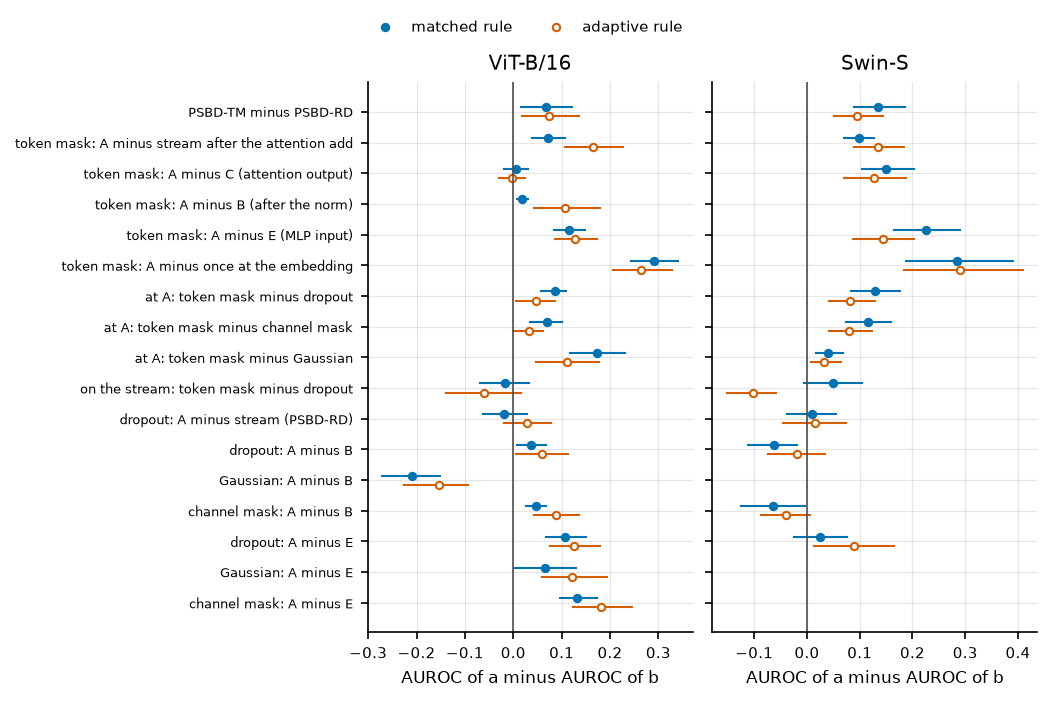

n  \
architecture contrast                                           rule           
vit          PSBD-TM minus PSBD-RD                              matched   56   
                                                                adaptive  56   
             token mask: A minus stream after the attention add matched   56   
                                                                adaptive  56   
             token mask: A minus C (attention output)           matched   56   
                                                                adaptive  56   
             token mask: A minus B (after the norm)             matched   36   
                                                                adaptive  36   
             token mask: A minus E (MLP input)                  matched   56   
                                                                adaptive  56   
             token mask: A minus once at the embedding          matched   36   
                                                                adaptive  36   
             at A: token mask minus dropout                     matched   56   
                                                                adaptive  56   
             at A: token mask minus channel mask                matched   56   
                                                                adaptive  56   
             at A: token mask minus Gaussian                    matched   56   
                                                                adaptive  56   
             on the stream: token mask minus dropout            matched   56   
                                                                adaptive  56   
             dropout: A minus stream (PSBD-RD)                  matched   56   
                                                                adaptive  56   
             dropout: A minus B                                 matched   56   
                                                                adaptive  56   
             Gaussian: A minus B                                matched   34   
                                                                adaptive  19   
             channel mask: A minus B                            matched   36   
                                                                adaptive  36   
             dropout: A minus E                                 matched   56   
                                                                adaptive  56   
             Gaussian: A minus E                                matched   35   
                                                                adaptive  35   
             channel mask: A minus E                            matched   36   
                                                                adaptive  36   
swin         PSBD-TM minus PSBD-RD                              matched   65   
                                                                adaptive  63   
             token mask: A minus stream after the attention add matched   63   
                                                                adaptive  63   
             token mask: A minus C (attention output)           matched   65   
                                                                adaptive  63   
             token mask: A minus E (MLP input)                  matched   63   
                                                                adaptive  63   
             token mask: A minus once at the embedding          matched   26   
                                                                adaptive  26   
             at A: token mask minus dropout                     matched   63   
                                                                adaptive  63   
             at A: token mask minus channel mask                matched   63   
                                                                adaptive  63   
             at A: token mask minus Gaussian                    matched   6

In [22]:
CONTRAST_LABELS = {
    "psbd_tm_vs_psbd_rd": "PSBD-TM minus PSBD-RD",
    "token_mask_attention_input_vs_stream": "token mask: A minus stream after the attention add",
    "token_mask_attention_input_vs_attention_output": "token mask: A minus C (attention output)",
    "token_mask_before_vs_after_norm": "token mask: A minus B (after the norm)",
    "token_mask_attention_input_vs_mlp_input": "token mask: A minus E (MLP input)",
    "token_mask_attention_input_vs_embedding": "token mask: A minus once at the embedding",
    "attention_input_token_mask_vs_dropout": "at A: token mask minus dropout",
    "attention_input_token_mask_vs_channel_mask": "at A: token mask minus channel mask",
    "attention_input_token_mask_vs_gaussian": "at A: token mask minus Gaussian",
    "stream_after_attention_token_mask_vs_dropout": "on the stream: token mask minus dropout",
    "dropout_attention_input_vs_stream": "dropout: A minus stream (PSBD-RD)",
    "dropout_before_vs_after_norm": "dropout: A minus B",
    "gaussian_before_vs_after_norm": "Gaussian: A minus B",
    "channel_mask_before_vs_after_norm": "channel mask: A minus B",
    "dropout_attention_input_vs_mlp_input": "dropout: A minus E",
    "gaussian_attention_input_vs_mlp_input": "Gaussian: A minus E",
    "channel_mask_attention_input_vs_mlp_input": "channel mask: A minus E",
}
names = list(CONTRAST_LABELS)
figure, axes = plt.subplots(1, 2, figsize=(TEXT_WIDTH, 4.3), sharey=True, constrained_layout=True)
for axis, architecture in zip(axes, ARCHITECTURES):
    contrasts = cache[architecture]["contrasts"]
    for row, name in enumerate(names):
        for rule, shift, filled in (("matched", -0.15, True), ("adaptive", 0.15, False)):
            entry = contrasts[name][f"{rule}_all"]
            if "auroc_gap" not in entry:
                continue
            low, high = entry["auroc_gap_ci"]
            color = "#0072B2" if rule == "matched" else "#D55E00"
            axis.plot([low, high], [row + shift] * 2, color=color, linewidth=1)
            axis.plot(entry["auroc_gap"], row + shift, "o", color=color, markerfacecolor=color if filled else "white", markersize=3.5,
                      label=f"{rule} rule" if row == 0 else None)
    axis.axvline(0, color="0.3", linewidth=0.8)
    axis.set_title(ARCHITECTURE_NAMES[architecture])
    axis.set_xlabel("AUROC of a minus AUROC of b")
axes[0].set_yticks(range(len(names)), [CONTRAST_LABELS[n] for n in names], fontsize=6)
axes[0].invert_yaxis()
legend_above(figure, list(axes), columns=2)
plt.show()

contrast_rows = []
for architecture in ARCHITECTURES:
    for name in names:
        for rule in ("matched", "adaptive"):
            entry = cache[architecture]["contrasts"][name][f"{rule}_all"]
            if "auroc_gap" in entry:
                contrast_rows.append({"architecture": architecture, "contrast": CONTRAST_LABELS[name], "rule": rule, "n": entry["n"],
                                      "gap": entry["auroc_gap"], "low": entry["auroc_gap_ci"][0], "high": entry["auroc_gap_ci"][1],
                                      "a wins": entry["a_wins"], "triggered shift a": entry["shift_backdoor_a"], "triggered shift b": entry["shift_backdoor_b"]})
contrast_frame = pd.DataFrame(contrast_rows).set_index(["architecture", "contrast", "rule"])


def gap(architecture, name, rule="matched"):
    entry = cache[architecture]["contrasts"][name][f"{rule}_all"]
    text = f"{entry['auroc_gap']:+.3f} [{entry['auroc_gap_ci'][0]:+.3f}, {entry['auroc_gap_ci'][1]:+.3f}] (n {entry['n']})" if "auroc_gap" in entry else "not cached"
    return text


contrast_frame.round(3)

In [23]:
display(Markdown(rf"""
Each row of the figure is 1 contrast, placement a minus placement b, with the filled blue point at the matched rule and the open orange point at the adaptive rule, each with its 95% interval. A point right of the zero line means a wins.

The site matters when the operator is token masking. At matched clean shift, token masking at A beats the same masking on the stream after the attention add by {gap("vit", "token_mask_attention_input_vs_stream")} on ViT and {gap("swin", "token_mask_attention_input_vs_stream")} on Swin, beats it at the MLP input by {gap("vit", "token_mask_attention_input_vs_mlp_input")} and {gap("swin", "token_mask_attention_input_vs_mlp_input")}. It beats masking once at the embedding by {gap("vit", "token_mask_attention_input_vs_embedding")} and {gap("swin", "token_mask_attention_input_vs_embedding")}. Against its twin at the attention output (site C) it ties on ViT, {gap("vit", "token_mask_attention_input_vs_attention_output")}. It wins on Swin, {gap("swin", "token_mask_attention_input_vs_attention_output")}.

The operator matters at the site. At A, token masking beats dropout by {gap("vit", "attention_input_token_mask_vs_dropout")} on ViT and {gap("swin", "attention_input_token_mask_vs_dropout")} on Swin, channel masking by {gap("vit", "attention_input_token_mask_vs_channel_mask")} and {gap("swin", "attention_input_token_mask_vs_channel_mask")}. It beats Gaussian noise by {gap("vit", "attention_input_token_mask_vs_gaussian")} and {gap("swin", "attention_input_token_mask_vs_gaussian")}. The site alone does not help dropout: dropout at A against dropout on the stream (PSBD-RD) is {gap("vit", "dropout_attention_input_vs_stream")} on ViT and {gap("swin", "dropout_attention_input_vs_stream")} on Swin. And the operator alone does not help on the stream: token masking against dropout there is {gap("vit", "stream_after_attention_token_mask_vs_dropout")} on ViT.

So neither factor explains the win on its own. Whole-token masking wins only where the stream is untouched and attention has not yet read the tokens, and a branch input without whole-token masking is no better than the stream. Every gap survives at the matched rule, so none of them is an artifact of one placement perturbing harder, the first negative explanation of step 12. What the contrasts cannot say is what happens to the trigger inside the network under each probe, which steps 10 and 11 measure.
"""))


Each row of the figure is 1 contrast, placement a minus placement b, with the filled blue point at the matched rule and the open orange point at the adaptive rule, each with its 95% interval. A point right of the zero line means a wins.

The site matters when the operator is token masking. At matched clean shift, token masking at A beats the same masking on the stream after the attention add by +0.071 [+0.038, +0.106] (n 56) on ViT and +0.098 [+0.070, +0.127] (n 63) on Swin, beats it at the MLP input by +0.115 [+0.083, +0.149] (n 56) and +0.226 [+0.165, +0.290] (n 63). It beats masking once at the embedding by +0.290 [+0.243, +0.340] (n 36) and +0.283 [+0.188, +0.390] (n 26). Against its twin at the attention output (site C) it ties on ViT, +0.005 [-0.020, +0.031] (n 56). It wins on Swin, +0.151 [+0.103, +0.202] (n 65).

The operator matters at the site. At A, token masking beats dropout by +0.086 [+0.058, +0.110] (n 56) on ViT and +0.128 [+0.084, +0.176] (n 63) on Swin, channel masking by +0.070 [+0.034, +0.101] (n 56) and +0.115 [+0.074, +0.159] (n 63). It beats Gaussian noise by +0.173 [+0.117, +0.230] (n 56) and +0.041 [+0.018, +0.068] (n 63). The site alone does not help dropout: dropout at A against dropout on the stream (PSBD-RD) is -0.018 [-0.063, +0.029] (n 56) on ViT and +0.009 [-0.038, +0.056] (n 63) on Swin. And the operator alone does not help on the stream: token masking against dropout there is -0.017 [-0.068, +0.033] (n 56) on ViT.

So neither factor explains the win on its own. Whole-token masking wins only where the stream is untouched and attention has not yet read the tokens, and a branch input without whole-token masking is no better than the stream. Every gap survives at the matched rule, so none of them is an artifact of one placement perturbing harder, the first negative explanation of step 12. What the contrasts cannot say is what happens to the trigger inside the network under each probe, which steps 10 and 11 measure.


## Step 9. Every operator at every disturbance

The matched rule compares placements at 1 clean shift of 0.6. A single point could hide a crossing. The question is whether any other operator at the attention input, at any rate at all, reaches token masking's AUROC at the same disturbance of clean predictions. If token masking were only a stronger form of dropout, dropout at a higher rate would reach the same curve.

What is measured: every rate of every cached sweep (the ladder), with its clean validation shift ratio on the x axis and its mean AUROC on the y axis, averaged over the models carrying that placement (`sites.model_row`, field `ladder`). The top row holds the 4 operators at site A, the bottom row token masking at every site. The dotted vertical line is the matched target 0.6 and the dashed one the adaptive target 0.8.

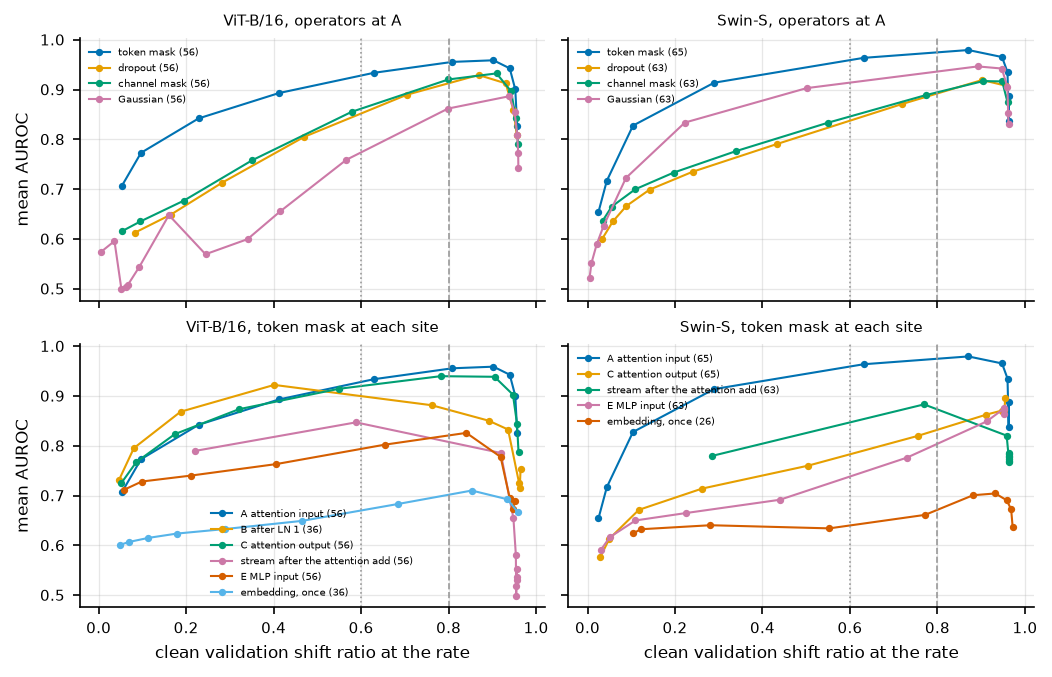

ViT-B/16, token mask                        0.959
ViT-B/16, dropout                           0.929
ViT-B/16, channel mask                      0.933
ViT-B/16, Gaussian                          0.887
ViT-B/16, A attention input                 0.959
ViT-B/16, B after LN 1                      0.922
ViT-B/16, C attention output                0.940
ViT-B/16, stream after the attention add    0.847
ViT-B/16, E MLP input                       0.826
ViT-B/16, embedding, once                   0.710
Swin-S, token mask                          0.980
Swin-S, dropout                             0.919
Swin-S, channel mask                        0.917
Swin-S, Gaussian                            0.947
Swin-S, A attention input                   0.980
Swin-S, C attention output                  0.896
Swin-S, stream after the attention add      0.883
Swin-S, E MLP input                         0.876
Swin-S, embedding, once                     0.704
Name: best AUROC on the ladder, dtype: float64

In [24]:
def ladder_curve(architecture, key):
    points = collections.defaultdict(list)
    for row in cache[architecture]["per_model"]:
        reading = row["placements"].get(key)
        if reading is None:
            continue
        for rate, shift_validation, _, _, auroc in reading["ladder"]:
            if shift_validation is not None:
                points[rate].append((shift_validation, auroc))
    curve = sorted((np.mean([s for s, _ in v]), np.mean([a for _, a in v]), len(v)) for v in points.values())
    return curve


OPERATOR_KEYS = {"token mask": "attention_input__token_mask", "dropout": "attention_input__dropout",
                 "channel mask": "attention_input__channel_mask", "Gaussian": "attention_input__gaussian"}
SITE_KEYS = {"A attention input": "attention_input__token_mask", "B after LN 1": "attention_input_after_norm__token_mask",
             "C attention output": "attention_output__token_mask", "stream after the attention add": "stream_after_attention__token_mask",
             "E MLP input": "mlp_input__token_mask", "embedding, once": "embedding__token_mask"}
figure, axes = plt.subplots(2, 2, figsize=(TEXT_WIDTH, 4.4), sharex=True, sharey=True, constrained_layout=True)
best = {}
for column, architecture in enumerate(ARCHITECTURES):
    for row, (title, keys) in enumerate((("operators at A", OPERATOR_KEYS), ("token mask at each site", SITE_KEYS))):
        axis = axes[row, column]
        for label, key in keys.items():
            curve = ladder_curve(architecture, key)
            if not curve:
                continue
            axis.plot([c[0] for c in curve], [c[1] for c in curve], marker="o", markersize=2.5, linewidth=1, label=f"{label} ({max(c[2] for c in curve)})")
            best[(architecture, label)] = max(c[1] for c in curve)
        axis.axvline(0.6, color="0.6", linestyle=":", linewidth=0.8)
        axis.axvline(0.8, color="0.6", linestyle="--", linewidth=0.8)
        axis.set_title(f"{ARCHITECTURE_NAMES[architecture]}, {title}", fontsize=7)
        axis.legend(fontsize=5)
for axis in axes[1]:
    axis.set_xlabel("clean validation shift ratio at the rate")
for axis in axes[:, 0]:
    axis.set_ylabel("mean AUROC")
plt.show()
pd.Series({f"{ARCHITECTURE_NAMES[a]}, {label}": v for (a, label), v in best.items()}, name="best AUROC on the ladder").round(3)

In [25]:
display(Markdown(rf"""
Each curve is 1 placement, and each point 1 swept rate averaged over the models that carry it (the count is in the legend). On ViT the token mask curve at A lies above every other operator at every clean shift. Its best point, {best[("vit", "token mask")]:.3f}, is above the best of dropout ({best[("vit", "dropout")]:.3f}), channel masking ({best[("vit", "channel mask")]:.3f}) and the Gaussian ({best[("vit", "Gaussian")]:.3f}). On Swin the ordering is the same, {best[("swin", "token mask")]:.3f} against {best[("swin", "dropout")]:.3f}, {best[("swin", "channel mask")]:.3f} and {best[("swin", "Gaussian")]:.3f}. No rate of dropout reaches token masking at any disturbance, so whole-token masking is not a stronger dropout, a claim step 12 takes up. The bottom row shows the same for the sites: token masking is best at A on both architectures, the embedding (masking once, for the whole network) is the worst site on both, and on ViT the curve after LN 1 (site B, cached on fewer models) is close to A at low disturbance and falls away at high disturbance. The means pool different model sets at different rates when a placement is missing on some models, so a small gap between 2 curves with different counts is not a comparison, and step 8's paired contrasts are.
"""))


Each curve is 1 placement, and each point 1 swept rate averaged over the models that carry it (the count is in the legend). On ViT the token mask curve at A lies above every other operator at every clean shift. Its best point, 0.959, is above the best of dropout (0.929), channel masking (0.933) and the Gaussian (0.887). On Swin the ordering is the same, 0.980 against 0.919, 0.917 and 0.947. No rate of dropout reaches token masking at any disturbance, so whole-token masking is not a stronger dropout, a claim step 12 takes up. The bottom row shows the same for the sites: token masking is best at A on both architectures, the embedding (masking once, for the whole network) is the worst site on both, and on ViT the curve after LN 1 (site B, cached on fewer models) is close to A at low disturbance and falls away at high disturbance. The means pool different model sets at different rates when a placement is missing on some models, so a small gap between 2 curves with different counts is not a comparison, and step 8's paired contrasts are.


## Step 10. The causal site and operator grid at matched clean disturbance

The cached sweeps give AUROC, which aggregates many things. The causal question is sharper: at equal damage to clean predictions, how many triggered predictions does each probe leave, and is that because of what it does to the trigger's tokens.

What is measured (`sites.py`, records under `sites/`): on every patch model (15 ViT, 14 Swin), for each of 6 sites and 6 operators, the rate is first set so that the probe changes 60% of the model's own clean predictions on its 256 clean pairs (`sites.calibrate_rate`, 7 bisection steps of 2 passes, linear in the rate for masks and dropout, logarithmic for the 2 noises). The cached matched rates land anywhere between 0.45 and 0.76 of clean change on these models, which is too loose for this question. At that rate the probe runs 6 passes, reseeded per pass so that each clean image and its triggered twin draw the same masks, on 4 sets of positions: all tokens (the library probe), the trigger's tokens only, as many random tokens per block (2 draws seeded per model) and every token but the trigger's. The restricted variants run the library operator on the whole activation and keep its output only at the chosen positions (`tokens.PositionRestricted`), so the random draw and any statistic the operator reads are the unrestricted probe's.

The figure shows triggered survival with the probe on all tokens. Every cell has changed 60% of clean predictions, so a cell's value is directly comparable to every other cell: the higher, the more a triggered prediction outlasts a clean one under that probe. A cell the calibration could not bring to 60% within its rate bounds is marked in the table.

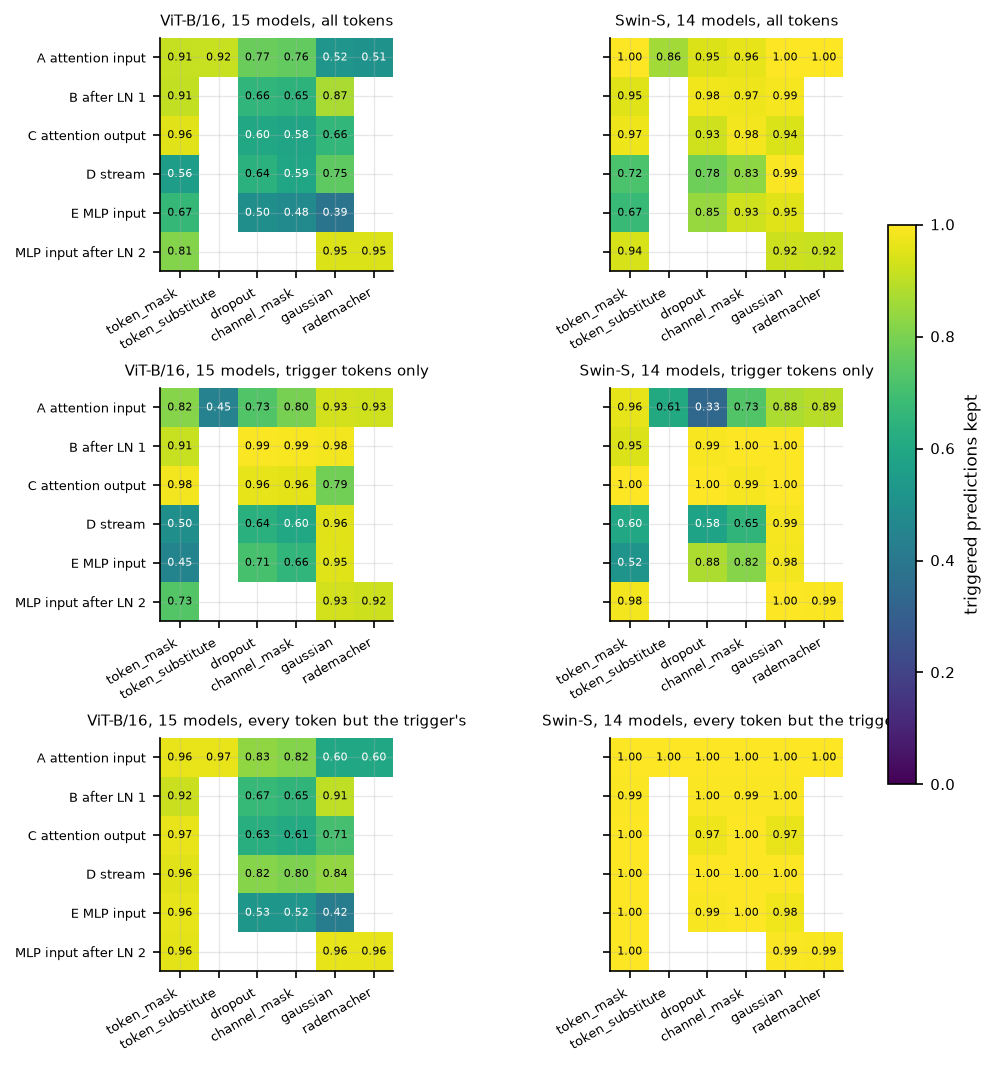

models   rate  \
architecture site                       operator                          
swin         attention_input            channel_mask          14  0.530   
                                        dropout               14  0.652   
                                        gaussian              14  1.069   
                                        rademacher            14  1.036   
                                        token_mask            14  0.381   
                                        token_substitute      14  0.523   
             attention_input_after_norm channel_mask          14  0.595   
                                        dropout               14  0.714   
                                        gaussian              14  1.898   
                                        token_mask            14  0.480   
             attention_output           channel_mask          14  0.457   
                                        dropout               14  0.411   
                                        gaussian              14  0.862   
                                        token_mask            14  0.453   
             mlp_input                  channel_mask          14  0.424   
                                        dropout               14  0.423   
                                        gaussian              14  0.828   
                                        token_mask            14  0.472   
             mlp_input_after_norm       gaussian              14  0.977   
                                        rademacher            14  0.980   
                                        token_mask            14  0.376   
             stream                     channel_mask          14  0.049   
                                        dropout               14  0.060   
                                        gaussian              14  0.238   
                                        token_mask            14  0.045   
vit          attention_input            channel_mask          15  0.413   
                                        dropout               15  0.458   
                                        gaussian              15  0.722   
                                        rademacher            15  0.739   
                                        token_mask            15  0.374   
                                        token_substitute      15  0.579   
             attention_input_after_norm channel_mask          15  0.493   
                                        dropout               15  0.541   
                                        gaussian              15  2.555   
                                        token_mask            15  0.377   
             attention_output           channel_mask          15  0.552   
                                        dropout               15  0.548   
                                        gaussian              15  1.294   
                                        token_mask            15  0.441   
             mlp_input                  channel_mask          15  0.432   
                                        dropout               15  0.415   
                                        gaussian              15  0.856   
                                        token_mask            15  0.396   
             mlp_input_after_norm       gaussian              15  1.380   
                                        rademacher            15  1.405   
                                        token_mask            15  0.370   
             stream                     channel_mask          15  0.056   
                                        dropout               15  0.052   
                                        gaussian              15  0.249   
                                        token_mask            15  0.057   

                                                          reached  \
architecture site                       operator                    
swin         attent

In [26]:
GRID_SITES = ("attention_input", "attention_input_after_norm", "attention_output", "stream", "mlp_input", "mlp_input_after_norm")
GRID_SITE_LABELS = ("A attention input", "B after LN 1", "C attention output", "D stream", "E MLP input", "MLP input after LN 2")
GRID_OPERATORS = ("token_mask", "token_substitute", "dropout", "channel_mask", "gaussian", "rademacher")


def trigger_dependent(records):
    kept = [r for r in records if group_of(r) in ("badnet_a2o", "tact", "lc")]
    return kept


def grid_matrix(records, variant, field="triggered_kept"):
    matrix = np.full((len(GRID_SITES), len(GRID_OPERATORS)), np.nan)
    for i, site in enumerate(GRID_SITES):
        for j, operator in enumerate(GRID_OPERATORS):
            values = [r["placements"][f"{site}__{operator}"][variant][field] for r in records if f"{site}__{operator}" in r["placements"]]
            values = [v for v in values if v == v]
            if values:
                matrix[i, j] = np.mean(values)
    return matrix


grid_records = {a: trigger_dependent([r for r in site_records if r["architecture"] == a]) for a in ARCHITECTURES}
figure, axes = plt.subplots(3, 2, figsize=(TEXT_WIDTH, 7.0), constrained_layout=True)
for column, architecture in enumerate(ARCHITECTURES):
    for row, (variant, title) in enumerate((("all_tokens", "all tokens"), ("trigger_only", "trigger tokens only"), ("all_but_trigger", "every token but the trigger's"))):
        axis = axes[row, column]
        matrix = grid_matrix(grid_records[architecture], variant)
        image = axis.imshow(matrix, vmin=0, vmax=1, cmap="viridis")
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                if matrix[i, j] == matrix[i, j]:
                    axis.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", fontsize=5.5, color="white" if matrix[i, j] < 0.6 else "black")
        axis.set_xticks(range(len(GRID_OPERATORS)), GRID_OPERATORS, rotation=30, ha="right", fontsize=6)
        axis.set_yticks(range(len(GRID_SITES)), GRID_SITE_LABELS if column == 0 else [], fontsize=6)
        axis.set_title(f"{ARCHITECTURE_NAMES[architecture]}, {len(grid_records[architecture])} models, {title}", fontsize=7)
figure.colorbar(image, ax=axes, shrink=0.6, label="triggered predictions kept")
plt.show()

grid_rows = []
for architecture in ARCHITECTURES:
    for record in grid_records[architecture]:
        for key, placement in record["placements"].items():
            site, operator = key.split("__")
            grid_rows.append({"architecture": architecture, "model": record["folder"], "site": site, "operator": operator, "rate": placement["rate"],
                              "calibration reached": placement["calibration"]["reached"], "clean change": 1 - placement["all_tokens"]["clean_kept"],
                              "all tokens": placement["all_tokens"]["triggered_kept"], "trigger only": placement["trigger_only"]["triggered_kept"],
                              "random": placement["random_same_count"]["triggered_kept"], "all but trigger": placement["all_but_trigger"]["triggered_kept"]})
grid_frame = pd.DataFrame(grid_rows)
grid_table = grid_frame.groupby(["architecture", "site", "operator"]).agg(
    models=("model", "count"), rate=("rate", "mean"), reached=("calibration reached", "sum"), clean_change=("clean change", "mean"),
    all_tokens=("all tokens", "mean"), trigger_only=("trigger only", "mean"), random=("random", "mean"), all_but_trigger=("all but trigger", "mean"))


def grid_cell(architecture, site, operator, column="all_tokens"):
    try:
        value = float(grid_table.loc[(architecture, site, operator), column])
    except KeyError:
        value = float("nan")
    return value


grid_summary_text = " ".join(
    f"On {ARCHITECTURE_NAMES[a]} the probe on all tokens keeps {grid_cell(a, 'attention_input', 'token_mask'):.3f} of triggered predictions with token masking at A, "
    f"against {grid_cell(a, 'stream', 'dropout'):.3f} for PSBD-RD, {grid_cell(a, 'attention_input', 'dropout'):.3f} for dropout at A, "
    f"{grid_cell(a, 'attention_input', 'channel_mask'):.3f} for channel masking at A and {grid_cell(a, 'attention_input', 'gaussian'):.3f} for Gaussian noise at A. "
    f"Token masking itself keeps {grid_cell(a, 'attention_output', 'token_mask'):.3f} at C, {grid_cell(a, 'attention_input_after_norm', 'token_mask'):.3f} at B, "
    f"{grid_cell(a, 'stream', 'token_mask'):.3f} on the stream and {grid_cell(a, 'mlp_input', 'token_mask'):.3f} at E."
    for a in ARCHITECTURES
)
grid_summary_text += (
    " The random control keeps at least "
    f"{grid_table['random'].min():.3f} in every cell, so no probe hurts a triggered prediction by touching an arbitrary set of tokens. "
    "The restricted variants separate where each probe does its damage. On ViT BadNets, Gaussian noise at A on the trigger tokens alone keeps "
    f"{grid_cell('vit', 'attention_input', 'gaussian', 'trigger_only'):.3f} and on every other token {grid_cell('vit', 'attention_input', 'gaussian', 'all_but_trigger'):.3f}, "
    "so the Gaussian breaks triggered predictions through the tokens that do not carry the trigger, which step 12's coupling test explains. "
    f"Token masking at A on the trigger tokens alone keeps {grid_cell('vit', 'attention_input', 'token_mask', 'trigger_only'):.3f}, less than on all tokens "
    f"({grid_cell('vit', 'attention_input', 'token_mask'):.3f}): masking the rest of the image as well protects the triggered prediction, "
    "the same pattern step 6 found for PSBD-RD. Why is a **hypothesis** here (the competing class loses evidence too), since the records hold no logits. "
    "The bottom row isolates what whole-token masking does differently. On ViT, token masking on every token but the trigger's keeps "
    f"{grid_cell('vit', 'attention_input', 'token_mask', 'all_but_trigger'):.3f} of triggered predictions, while dropout there keeps "
    f"{grid_cell('vit', 'attention_input', 'dropout', 'all_but_trigger'):.3f}, channel masking {grid_cell('vit', 'attention_input', 'channel_mask', 'all_but_trigger'):.3f} "
    f"and Gaussian noise {grid_cell('vit', 'attention_input', 'gaussian', 'all_but_trigger'):.3f}: removing the other tokens outright barely disturbs the trigger's route, "
    "corrupting them partly does. On Swin the other tokens are harmless under every operator at A, and the difference sits in the middle row instead: "
    f"token masking on the trigger tokens alone keeps {grid_cell('swin', 'attention_input', 'token_mask', 'trigger_only'):.3f}, dropout on them "
    f"{grid_cell('swin', 'attention_input', 'dropout', 'trigger_only'):.3f} and channel masking {grid_cell('swin', 'attention_input', 'channel_mask', 'trigger_only'):.3f}, "
    "so a trigger token hidden outright in some blocks does less harm than one read corrupted in every block."
)
grid_table.round(3)

In [27]:
display(Markdown(rf"""
The top row is the probe on all tokens, the middle row the probe restricted to the trigger's tokens and the bottom row the probe on every other token, all at the same calibrated rate. The table gives each cell's mean calibrated rate, the clean change actually reached (the target is 0.6), and survival under all 4 position sets.

{grid_summary_text}
"""))


The top row is the probe on all tokens, the middle row the probe restricted to the trigger's tokens and the bottom row the probe on every other token, all at the same calibrated rate. The table gives each cell's mean calibrated rate, the clean change actually reached (the target is 0.6), and survival under all 4 position sets.

On ViT-B/16 the probe on all tokens keeps 0.912 of triggered predictions with token masking at A, against 0.638 for PSBD-RD, 0.770 for dropout at A, 0.760 for channel masking at A and 0.520 for Gaussian noise at A. Token masking itself keeps 0.957 at C, 0.908 at B, 0.555 on the stream and 0.666 at E. On Swin-S the probe on all tokens keeps 0.997 of triggered predictions with token masking at A, against 0.779 for PSBD-RD, 0.947 for dropout at A, 0.964 for channel masking at A and 0.996 for Gaussian noise at A. Token masking itself keeps 0.973 at C, 0.953 at B, 0.718 on the stream and 0.672 at E. The random control keeps at least 0.999 in every cell, so no probe hurts a triggered prediction by touching an arbitrary set of tokens. The restricted variants separate where each probe does its damage. On ViT BadNets, Gaussian noise at A on the trigger tokens alone keeps 0.930 and on every other token 0.598, so the Gaussian breaks triggered predictions through the tokens that do not carry the trigger, which step 12's coupling test explains. Token masking at A on the trigger tokens alone keeps 0.820, less than on all tokens (0.912): masking the rest of the image as well protects the triggered prediction, the same pattern step 6 found for PSBD-RD. Why is a **hypothesis** here (the competing class loses evidence too), since the records hold no logits. The bottom row isolates what whole-token masking does differently. On ViT, token masking on every token but the trigger's keeps 0.965 of triggered predictions, while dropout there keeps 0.834, channel masking 0.816 and Gaussian noise 0.598: removing the other tokens outright barely disturbs the trigger's route, corrupting them partly does. On Swin the other tokens are harmless under every operator at A, and the difference sits in the middle row instead: token masking on the trigger tokens alone keeps 0.963, dropout on them 0.332 and channel masking 0.727, so a trigger token hidden outright in some blocks does less harm than one read corrupted in every block.


## Step 11. Why whole tokens

Step 10 says which probes leave a triggered prediction alone. This step asks what each probe does to the trigger's own evidence on the way, and it is the direct test of "whole tokens beat partial perturbation".

What is measured, during the all-tokens runs of step 10 (`sites.all_tokens_readout`): in every block, what attention reads at the trigger's tokens (the attention module's input, which includes a probe placed before or after the norm) and the residual stream entering the block there, for each clean image and its triggered twin under the same random draw. The **trigger signal** at a block is the difference the trigger makes to those vectors on the unperturbed model, and the share of it that survives is its projection under the probe (`tokens.signal_retained`):

$$r_b = \frac{\sum_{t\in T_b}\langle \tilde a_{b,t}-a'_{b,t},\; \tilde u_{b,t}-u_{b,t}\rangle}{\sum_{t\in T_b}\lVert \tilde u_{b,t}-u_{b,t}\rVert^2}$$

| symbol | meaning |
|---|---|
| $T_b$ | the trigger tokens of block $b$ |
| $\tilde u_{b,t}$, $u_{b,t}$ | the unperturbed vector at token $t$ of block $b$, triggered image and its clean twin |
| $\tilde a_{b,t}$, $a'_{b,t}$ | the same vectors under the probe, with 1 shared random draw for the 2 images |
| $r_b$ | trigger signal retained at block $b$, pooled over images and passes |

$r_b$ is 1 when the trigger reads exactly as on the unperturbed model and 0 when the probe erased it. A masked token contributes 0 (both images read the same constant) and a visible token 1, so under token masking $r_b$ is close to the share of visible trigger tokens. Under dropout every token keeps a part of its signal.

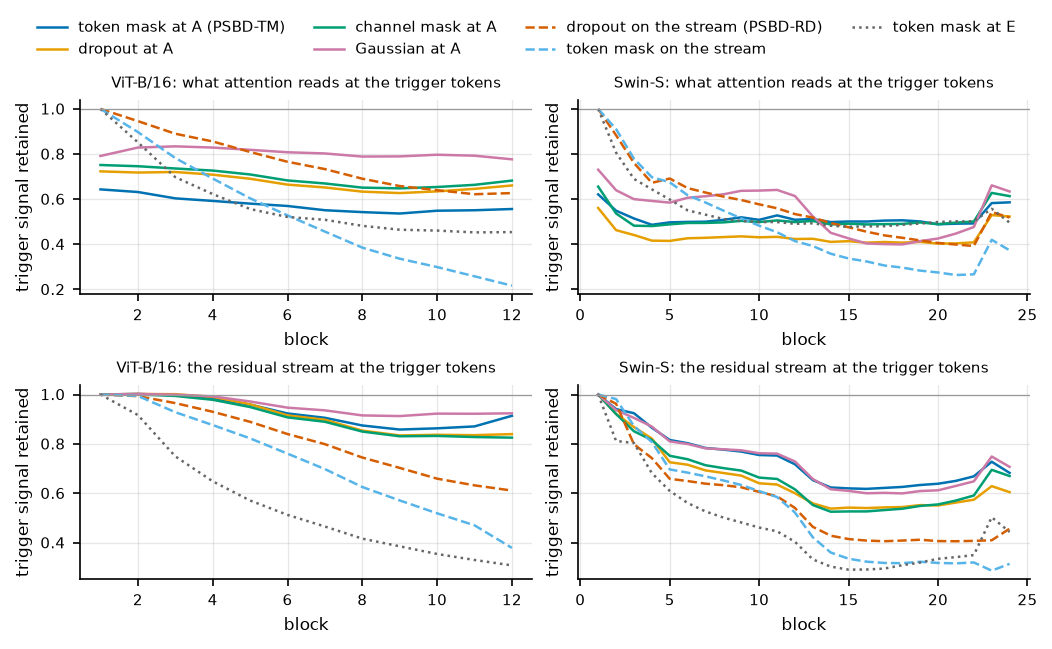

ViT-B/16, read, token mask at A (PSBD-TM)            0.548
ViT-B/16, read, dropout at A                         0.642
ViT-B/16, read, channel mask at A                    0.662
ViT-B/16, read, Gaussian at A                        0.789
ViT-B/16, read, dropout on the stream (PSBD-RD)      0.637
ViT-B/16, read, token mask on the stream             0.278
ViT-B/16, read, token mask at E                      0.458
ViT-B/16, stream, token mask at A (PSBD-TM)          0.877
ViT-B/16, stream, dropout at A                       0.837
ViT-B/16, stream, channel mask at A                  0.829
ViT-B/16, stream, Gaussian at A                      0.920
ViT-B/16, stream, dropout on the stream (PSBD-RD)    0.651
ViT-B/16, stream, token mask on the stream           0.485
ViT-B/16, stream, token mask at E                    0.345
Swin-S, read, token mask at A (PSBD-TM)              0.538
Swin-S, read, dropout at A                           0.466
Swin-S, read, channel mask at A                      0.5

In [28]:
RETENTION_PLACEMENTS = {
    "token mask at A (PSBD-TM)": ("attention_input__token_mask", "#0072B2", "-"),
    "dropout at A": ("attention_input__dropout", "#E69F00", "-"),
    "channel mask at A": ("attention_input__channel_mask", "#009E73", "-"),
    "Gaussian at A": ("attention_input__gaussian", "#CC79A7", "-"),
    "dropout on the stream (PSBD-RD)": ("stream__dropout", "#D55E00", "--"),
    "token mask on the stream": ("stream__token_mask", "#56B4E9", "--"),
    "token mask at E": ("mlp_input__token_mask", "0.4", ":"),
}


def mean_curve(records, key, curve):
    curves = [[np.nan if v is None else v for v in r["placements"][key]["all_tokens"][curve]] for r in records if key in r["placements"]]
    mean = np.nanmean(curves, axis=0) if curves else None
    return mean


figure, axes = plt.subplots(2, 2, figsize=(TEXT_WIDTH, 3.8), sharey="row", constrained_layout=True)
retention = {}
for column, architecture in enumerate(ARCHITECTURES):
    for row, (curve, title) in enumerate((("read_signal_retained", "what attention reads at the trigger tokens"), ("stream_signal_retained", "the residual stream at the trigger tokens"))):
        axis = axes[row, column]
        for label, (key, color, style) in RETENTION_PLACEMENTS.items():
            values = mean_curve(grid_records[architecture], key, curve)
            if values is None:
                continue
            retention[(architecture, curve, label)] = values
            axis.plot(range(1, len(values) + 1), values, color=color, linestyle=style, linewidth=1.2, label=label)
        axis.axhline(1, color="0.6", linewidth=0.6)
        axis.set_title(f"{ARCHITECTURE_NAMES[architecture]}: {title}", fontsize=7)
        axis.set_xlabel("block")
    axes[0, column].set_ylabel("trigger signal retained")
    axes[1, column].set_ylabel("trigger signal retained")
legend_above(figure, list(axes.flat), columns=4)
plt.show()
late = {key: float(np.nanmean(values[-4:])) for key, values in retention.items()}
pd.Series({f"{ARCHITECTURE_NAMES[a]}, {c.split('_')[0]}, {label}": v for (a, c, label), v in late.items()}, name="mean over the last 4 blocks").round(3)

In [29]:
display(Markdown(rf"""
Top row: the trigger signal in what attention reads, per block. Bottom row: the trigger signal in the residual stream at the trigger tokens. Every probe runs at the rate that changes 60% of clean predictions, so the curves compare operators at equal clean damage.

The bottom row confirms the stream account. Under token masking at A the trigger's stream entry keeps {late[("vit", "stream_signal_retained", "token mask at A (PSBD-TM)")]:.2f} of its signal over the last 4 ViT blocks and {late[("swin", "stream_signal_retained", "token mask at A (PSBD-TM)")]:.2f} over the last 4 Swin blocks, while dropout on the stream (PSBD-RD) keeps {late[("vit", "stream_signal_retained", "dropout on the stream (PSBD-RD)")]:.2f} and {late[("swin", "stream_signal_retained", "dropout on the stream (PSBD-RD)")]:.2f}, the stored content eroded block after block, and token masking on the stream or at E keeps the least.

The top row refutes the simplest reading of "whole tokens beat partial perturbation". Token masking at A does not leave more of the trigger's signal in what attention reads: over the last 4 ViT blocks it leaves {late[("vit", "read_signal_retained", "token mask at A (PSBD-TM)")]:.2f}, less than dropout ({late[("vit", "read_signal_retained", "dropout at A")]:.2f}), channel masking ({late[("vit", "read_signal_retained", "channel mask at A")]:.2f}) or Gaussian noise ({late[("vit", "read_signal_retained", "Gaussian at A")]:.2f}), and it still keeps the most triggered predictions (step 10). So the amount of trigger signal that survives in the reads is not why it wins. Step 10's restricted variants give the isolating answer instead: on ViT whole-token masking of the other tokens barely disturbs the trigger's route while partial corruption of them does, and on Swin whole-token masking of the trigger's own tokens does little harm while partial corruption of them does. What the partly corrupted tokens do to the class token's read is a **hypothesis** (they are inputs the network never saw and write into every read, where a masked token contributes 1 constant the class token can learn to ignore), which the sink measurement below bears on.
"""))


Top row: the trigger signal in what attention reads, per block. Bottom row: the trigger signal in the residual stream at the trigger tokens. Every probe runs at the rate that changes 60% of clean predictions, so the curves compare operators at equal clean damage.

The bottom row confirms the stream account. Under token masking at A the trigger's stream entry keeps 0.88 of its signal over the last 4 ViT blocks and 0.68 over the last 4 Swin blocks, while dropout on the stream (PSBD-RD) keeps 0.65 and 0.42, the stored content eroded block after block, and token masking on the stream or at E keeps the least.

The top row refutes the simplest reading of "whole tokens beat partial perturbation". Token masking at A does not leave more of the trigger's signal in what attention reads: over the last 4 ViT blocks it leaves 0.55, less than dropout (0.64), channel masking (0.66) or Gaussian noise (0.79), and it still keeps the most triggered predictions (step 10). So the amount of trigger signal that survives in the reads is not why it wins. Step 10's restricted variants give the isolating answer instead: on ViT whole-token masking of the other tokens barely disturbs the trigger's route while partial corruption of them does, and on Swin whole-token masking of the trigger's own tokens does little harm while partial corruption of them does. What the partly corrupted tokens do to the class token's read is a **hypothesis** (they are inputs the network never saw and write into every read, where a masked token contributes 1 constant the class token can learn to ignore), which the sink measurement below bears on.


### The masked tokens as 1 attention sink

With LayerNorm's epsilon of 1e-6 a zeroed token leaves LN 1 as exactly the norm's bias $\beta$, so every masked token of a block carries the same key $W_k\beta + b_k$ and the same value. The theory memo predicted that the masked set then acts as 1 attention sink whose mass grows with the number masked. `token_substitute` replaces a token with another real token of the same image and has no such sink, which is the literature memo's L22 comparison.

What is measured (`mechanics.py`, part `sink`, on the ViT patch models and the 1 per attack and dataset global models): PSBD-TM's operator and `token_substitute` at rates 0.1, 0.3, 0.5, 0.7 and 0.9, 1 seeded pass on the 256 pairs. The class token's attention weights are recomputed from the attention module's input and the module's own projection weights (torchvision calls attention without returning weights), averaged over the 12 heads, and summed over the replaced positions. If the masked tokens were ordinary, their mass would equal their share of the tokens. The check that masked rows are identical after the norm is reported as their largest difference.

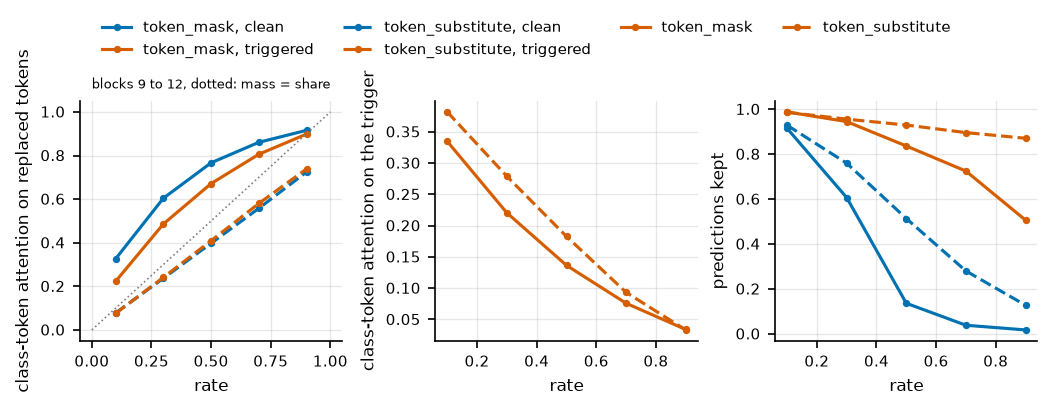

largest difference between 2 masked rows after LN 1, token_mask: 0.0


share  mass, blocks 1 to 4  \
operator         split     rate                               
token_mask       clean     0.1   0.100                0.096   
                           0.3   0.299                0.282   
                           0.5   0.499                0.460   
                           0.7   0.699                0.632   
                           0.9   0.900                0.805   
                 triggered 0.1   0.100                0.095   
                           0.3   0.299                0.280   
                           0.5   0.499                0.458   
                           0.7   0.699                0.631   
                           0.9   0.900                0.804   
token_substitute clean     0.1   0.100                0.089   
                           0.3   0.301                0.267   
                           0.5   0.501                0.443   
                           0.7   0.701                0.622   
                           0.9   0.900                0.801   
                 triggered 0.1   0.100                0.089   
                           0.3   0.301                0.267   
                           0.5   0.501                0.444   
                           0.7   0.701                0.623   
                           0.9   0.900                0.802   

                                 mass, blocks 9 to 12  \
operator         split     rate                         
token_mask       clean     0.1                  0.327   
                           0.3                  0.604   
                           0.5                  0.767   
                           0.7                  0.861   
                           0.9                  0.916   
                 triggered 0.1                  0.223   
                           0.3                  0.486   
                           0.5                  0.671   
                           0.7                  0.806   
                           0.9                  0.898   
token_substitute clean     0.1                  0.078   
                           0.3                  0.237   
                           0.5                  0.398   
                           0.7                  0.558   
                           0.9                  0.725   
                 triggered 0.1                  0.076   
                           0.3                  0.241   
                           0.5                  0.409   
                           0.7                  0.580   
                           0.9                  0.738   

                                 trigger mass, blocks 9 to 12   kept  
operator         split     rate                                       
token_mask       clean     0.1                          0.010  0.915  
                           0.3                          0.014  0.607  
                           0.5                          0.015  0.136  
                           0.7                          0.016  0.038  
                           0.9                          0.016  0.017  
                 triggered 0.1                          0.335  0.988  
                           0.3                          0.220  0.945  
                           0.5                          0.136  0.836  
                           0.7                          0.076  0.725  
                           0.9                          0.034  0.506  
token_substitute clean     0.1                          0.007  0.929  
                           0.3                          0.009  0.760  
                           0.5                          0.011  0.514  
                           0.7                          0.012  0.280  
                           0.9                          0.014  0.127  
                 triggered 0.1                          0.382  0.986  
                           0.3                          0.279  0.956  
                           0.5            

In [30]:
sink_rows = []
for record in mechanics_records:
    for operator in ("token_mask", "token_substitute"):
        for row in record["sink"][operator]:
            for split in ("clean", "triggered"):
                blocks = row[split]["blocks"]
                sink_rows.append({"model": record["folder"], "group": group_of(record), "operator": operator, "rate": row["rate"], "split": split,
                                  "kept": row[split]["kept"], "share": np.mean([b["masked_share"] for b in blocks]),
                                  "mass, blocks 1 to 4": np.mean([b["masked_mass"] for b in blocks[:4]]),
                                  "mass, blocks 9 to 12": np.mean([b["masked_mass"] for b in blocks[8:]]),
                                  "trigger mass, blocks 9 to 12": np.mean([b["trigger_mass"] for b in blocks[8:]]),
                                  "masked rows max difference": max(b["masked_rows_max_difference"] for b in blocks)})
sink = pd.DataFrame(sink_rows)
figure, axes = plt.subplots(1, 3, figsize=(TEXT_WIDTH, 2.2), constrained_layout=True)
for operator, style in (("token_mask", "-"), ("token_substitute", "--")):
    for split, color in (("clean", "#0072B2"), ("triggered", "#D55E00")):
        rows = sink[(sink.operator == operator) & (sink.split == split) & sink.group.isin(["badnet_a2o", "tact"])].groupby("rate").mean(numeric_only=True)
        axes[0].plot(rows.index, rows["mass, blocks 9 to 12"], linestyle=style, color=color, marker="o", markersize=2.5, label=f"{operator}, {split}")
        axes[2].plot(rows.index, rows["kept"], linestyle=style, color=color, marker="o", markersize=2.5, label=f"{operator}, {split}")
        if split == "triggered":
            axes[1].plot(rows.index, rows["trigger mass, blocks 9 to 12"], linestyle=style, color=color, marker="o", markersize=2.5, label=operator)
axes[0].plot([0, 1], [0, 1], color="0.5", linestyle=":", linewidth=0.8)
axes[0].set_xlabel("rate")
axes[0].set_ylabel("class-token attention on replaced tokens")
axes[0].set_title("blocks 9 to 12, dotted: mass = share", fontsize=6)
axes[1].set_xlabel("rate")
axes[1].set_ylabel("class-token attention on the trigger")
axes[2].set_xlabel("rate")
axes[2].set_ylabel("predictions kept")
legend_above(figure, list(axes), columns=4)
plt.show()
sink_patch = sink[sink.group.isin(["badnet_a2o", "tact"])]
sink_table = sink_patch.groupby(["operator", "split", "rate"])[["share", "mass, blocks 1 to 4", "mass, blocks 9 to 12", "trigger mass, blocks 9 to 12", "kept"]].mean().round(3)
print("largest difference between 2 masked rows after LN 1, token_mask:", sink[sink.operator == "token_mask"]["masked rows max difference"].max())
sink_table

In [31]:
display(Markdown(rf"""
Left: the class token's attention on the replaced positions in blocks 9 to 12, against the rate, for clean (blue) and triggered (orange) images, token masking solid and substitution dashed. The dotted diagonal is where a replaced token would sit if it were an ordinary token. Middle: the attention on the trigger tokens of triggered images. Right: the share of predictions kept.

Masked tokens are exactly identical after the norm (largest difference {sink[sink.operator == "token_mask"]["masked rows max difference"].max():.1f}). On clean images they draw far more attention than their share: at rate 0.1 the class token puts {sink_table.loc[("token_mask", "clean", 0.1), "mass, blocks 9 to 12"]:.2f} of its late attention on the 10% of masked tokens, and at 0.3 {sink_table.loc[("token_mask", "clean", 0.3), "mass, blocks 9 to 12"]:.2f}. That masked tokens draw more attention than their share is measured, with substitution as the control that has the same share and no constant key. That this extra attention is what breaks clean predictions is a **hypothesis**: the right panel shows substitution breaking fewer clean predictions at the same rate, and that difference also includes the loss of content, which the 2 operators do not share exactly. On triggered images the sink competes with the trigger and loses at low rates: the class token still puts {sink_table.loc[("token_mask", "triggered", 0.1), "trigger mass, blocks 9 to 12"]:.2f} of its late attention on the trigger at rate 0.1, and the late mass on masked tokens stays at {sink_table.loc[("token_mask", "triggered", 0.1), "mass, blocks 9 to 12"]:.2f}. Substitution has no sink, its mass tracks the share ({sink_table.loc[("token_substitute", "clean", 0.3), "mass, blocks 9 to 12"]:.2f} at 0.3), and it keeps {sink_table.loc[("token_substitute", "clean", 0.5), "kept"]:.2f} of clean predictions at rate 0.5 where token masking keeps {sink_table.loc[("token_mask", "clean", 0.5), "kept"]:.2f}. The literature memo's L22 argued, after Jain et al., that a zeroed token is an input the network never saw in training, so part of its effect is an artifact, and that replacing it with a real token avoids that. Here the constant is measurably a sink, and substitution is a much weaker probe at the same rate. Step 10's grid compares the 2 at equal clean damage.
"""))


Left: the class token's attention on the replaced positions in blocks 9 to 12, against the rate, for clean (blue) and triggered (orange) images, token masking solid and substitution dashed. The dotted diagonal is where a replaced token would sit if it were an ordinary token. Middle: the attention on the trigger tokens of triggered images. Right: the share of predictions kept.

Masked tokens are exactly identical after the norm (largest difference 0.0). On clean images they draw far more attention than their share: at rate 0.1 the class token puts 0.33 of its late attention on the 10% of masked tokens, and at 0.3 0.60. That masked tokens draw more attention than their share is measured, with substitution as the control that has the same share and no constant key. That this extra attention is what breaks clean predictions is a **hypothesis**: the right panel shows substitution breaking fewer clean predictions at the same rate, and that difference also includes the loss of content, which the 2 operators do not share exactly. On triggered images the sink competes with the trigger and loses at low rates: the class token still puts 0.34 of its late attention on the trigger at rate 0.1, and the late mass on masked tokens stays at 0.22. Substitution has no sink, its mass tracks the share (0.24 at 0.3), and it keeps 0.51 of clean predictions at rate 0.5 where token masking keeps 0.14. The literature memo's L22 argued, after Jain et al., that a zeroed token is an input the network never saw in training, so part of its effect is an artifact, and that replacing it with a real token avoids that. Here the constant is measurably a sink, and substitution is a much weaker probe at the same rate. Step 10's grid compares the 2 at equal clean damage.


## Step 12. The explanations that fail

Each plausible explanation below is stated as a claim, with what it predicts, the measurement that tests it and the verdict. Negative results carry the same weight as the positive ones above, since each one removes an account that a reader would otherwise reach for.

### "It just perturbs more"

Claim: PSBD-TM's adaptive rate damages the model more than PSBD-RD's, and more damage separates better. Prediction: at equal clean damage the gap disappears. Measurement: the paired contrasts of step 8 at the matched rule, the ladders of step 9, and the calibrated grid of step 10, all at equal clean damage.

In [32]:
display(Markdown(rf"""
Verdict: refuted. At the matched rule PSBD-TM leads PSBD-RD by {gap("vit", "psbd_tm_vs_psbd_rd")} on ViT and {gap("swin", "psbd_tm_vs_psbd_rd")} on Swin, the same order as at the adaptive rule ({gap("vit", "psbd_tm_vs_psbd_rd", "adaptive")} on ViT, and on Swin the paper's {PAPER["SwinGainRecommendedMinusPublished"]} [{PAPER["SwinGainRecommendedMinusPublishedLow"]}, {PAPER["SwinGainRecommendedMinusPublishedHigh"]}], `\SwinGainRecommendedMinusPublished`). On the ladders token masking at A lies above every other operator at every clean shift. And the adaptive rule itself equalizes damage: both placements change about {shifts["clean shift"].mean():.2f} of clean predictions there (step 1), since that is what the rule targets.
"""))


Verdict: refuted. At the matched rule PSBD-TM leads PSBD-RD by +0.067 [+0.017, +0.122] (n 56) on ViT and +0.135 [+0.089, +0.186] (n 65) on Swin, the same order as at the adaptive rule (+0.075 [+0.017, +0.136] (n 56) on ViT, and on Swin the paper's +0.096 [+0.051, +0.144], `\SwinGainRecommendedMinusPublished`). On the ladders token masking at A lies above every other operator at every clean shift. And the adaptive rule itself equalizes damage: both placements change about 0.87 of clean predictions there (step 1), since that is what the rule targets.


### "LayerNorm makes it stronger"

Claim: token masking wins because it sits before a LayerNorm, which either amplifies its effect or absorbs the competing operators. The absorption version was this project's account H47 and the literature memo's L25: normalizing each token by its own spread undoes part of an additive perturbation and none of a masking. Predictions: token masking before the norm beats token masking after it, and the Gaussian's deficit at A is the share the norm absorbs.

Measurements: the cached contrast of token masking at A against B (after the norm) and the same for dropout, channel masking and Gaussian noise (step 8), and the absorption record `results/<folder>/layernorm_absorption.json` (H47, copied into `sites/evidence.json`), which injects each operator at a set relative size before and after each norm and reads how much of the disturbance survives the norm. In plain words: a LayerNorm divides each token by its own spread, so noise that inflates the spread is partly divided away, while a zeroed token has no spread and simply becomes the norm's bias. The theory memo derived that for isotropic noise of relative size $\rho$ on a $d$ dimensional token the norm removes only the chord share $1 - D(\rho)/\rho$ with

$$D(\rho) = \sqrt{2 - \tfrac{2}{\sqrt{1+\rho^{2}}}} \approx \rho\left(1 - \tfrac{3\rho^{2}}{8}\right)$$

| symbol | meaning |
|---|---|
| $\rho$ | the noise norm relative to the centered token's norm |
| $D(\rho)$ | the relative disturbance left after the norm, with gain 1 and bias 0 |

which is 0.004, 0.015 and 0.055 at $\rho$ 0.1, 0.2 and 0.4.

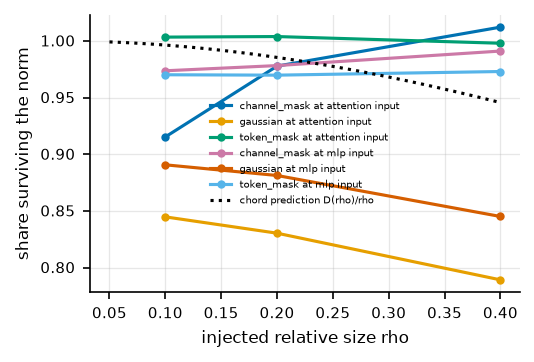

target                                0.1    0.2    0.4
position              operator                         
before_attention      channel_mask  1.000  1.000  1.000
                      gaussian      1.000  1.000  1.000
                      token_mask    1.000  1.000  1.000
before_attention_norm channel_mask  0.915  0.978  1.012
                      gaussian      0.845  0.830  0.789
                      token_mask    1.003  1.004  0.998
before_mlp            channel_mask  1.000  1.000  1.000
                      gaussian      1.000  1.000  1.000
                      token_mask    1.000  1.000  1.000
before_mlp_norm       channel_mask  0.974  0.978  0.991
                      gaussian      0.891  0.881  0.845
                      token_mask    0.970  0.970  0.973

In [33]:
absorption_rows = [
    {"model": folder, **row}
    for folder, record in evidence["layernorm_absorption"].items()
    for row in record["rows"]
]
absorption = pd.DataFrame(absorption_rows)
absorption_means = absorption.groupby(["position", "operator", "target"])["survival"].mean().unstack("target")
figure, axis = plt.subplots(figsize=(TEXT_WIDTH / 2, 2.3), constrained_layout=True)
for (position, operator), row in absorption_means.iterrows():
    if position not in ("before_attention_norm", "before_mlp_norm"):
        continue
    axis.plot(row.index, row.values, marker="o", markersize=3, label=f"{operator} at {position.replace('before_', '').replace('_norm', ' input')}")
rho = np.linspace(0.05, max(absorption["target"]), 50)
chord = np.sqrt(2 - 2 / np.sqrt(1 + rho**2)) / rho
axis.plot(rho, chord, color="black", linestyle=":", label="chord prediction D(rho)/rho")
axis.set_xlabel("injected relative size rho")
axis.set_ylabel("share surviving the norm")
axis.legend(fontsize=5)
plt.show()
absorption_means.round(3)

In [34]:
display(Markdown(rf"""
Verdict: refuted as the reason token masking wins, confirmed as a real but small effect. Token masking before the norm beats token masking after it by only {gap("vit", "token_mask_before_vs_after_norm")} on ViT at the matched rule, so the norm does not make masking stronger. For Gaussian noise the norm matters, and in the opposite direction from a helping LayerNorm: noise after the norm beats noise before it, {gap("vit", "gaussian_before_vs_after_norm")}, because the norm shrinks noise injected before it. The measured shrinkage is flat in $\rho$ (the figure's lines are nearly horizontal while the chord prediction, dotted, falls from 1 only slowly), so most of it is a linear attenuation, which a rescaled rate compensates exactly and which the matched rule therefore cancels. Absorption cannot explain the Gaussian's deficit at the matched rule, {gap("vit", "attention_input_token_mask_vs_gaussian")}. The coupling test below does, in part.
"""))


Verdict: refuted as the reason token masking wins, confirmed as a real but small effect. Token masking before the norm beats token masking after it by only +0.019 [+0.008, +0.031] (n 36) on ViT at the matched rule, so the norm does not make masking stronger. For Gaussian noise the norm matters, and in the opposite direction from a helping LayerNorm: noise after the norm beats noise before it, -0.209 [-0.271, -0.151] (n 34), because the norm shrinks noise injected before it. The measured shrinkage is flat in $\rho$ (the figure's lines are nearly horizontal while the chord prediction, dotted, falls from 1 only slowly), so most of it is a linear attenuation, which a rescaled rate compensates exactly and which the matched rule therefore cancels. Absorption cannot explain the Gaussian's deficit at the matched rule, +0.173 [+0.117, +0.230] (n 56). The coupling test below does, in part.


### The all-or-nothing reads, a positive account of the operator gap

Claim, from the theory memo: a patch-triggered prediction survives if at least 1 of its $mL$ reads is intact (an OR over reads), while a clean prediction needs the average fidelity of many reads (an AND). Token masking gives reads that are exactly intact or gone, and high-dimensional noise degrades every read by about the same amount, so at matched clean damage token masking separates at least as well whenever 1 exact read suffices. Prediction: the Gaussian minus token mask gap at A is negative, largest on patch triggers, smaller on global triggers whose read is itself an average, and near 0 where token masking also fails. Measurement: the matched-rule AUROC gap per attack from the cached sweeps.

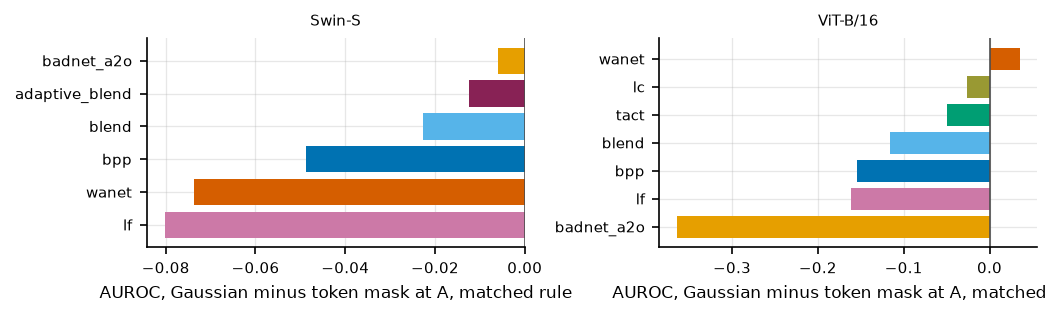

models  Gaussian minus token mask
architecture attack                                           
Swin-S       lf                  12                     -0.080
             wanet                8                     -0.074
             bpp                 12                     -0.049
             blend               12                     -0.023
             adaptive_blend       7                     -0.012
             badnet_a2o          12                     -0.006
ViT-B/16     badnet_a2o          12                     -0.365
             lf                  12                     -0.161
             bpp                 12                     -0.154
             blend               12                     -0.116
             tact                 4                     -0.049
             lc                   1                     -0.026
             wanet                3                      0.036

In [35]:
order_rows = []
for architecture in ARCHITECTURES:
    by_attack = collections.defaultdict(list)
    for row in cache[architecture]["per_model"]:
        a = row["placements"].get("attention_input__gaussian", {}).get("matched")
        b = row["placements"].get("attention_input__token_mask", {}).get("matched")
        if a and b:
            by_attack[row["attack"]].append(a["auroc"] - b["auroc"])
    for attack, values in by_attack.items():
        order_rows.append({"architecture": ARCHITECTURE_NAMES[architecture], "attack": attack, "models": len(values), "Gaussian minus token mask": np.mean(values)})
order = pd.DataFrame(order_rows).sort_values(["architecture", "Gaussian minus token mask"])
figure, axes = plt.subplots(1, 2, figsize=(TEXT_WIDTH, 2.0), constrained_layout=True)
for axis, (architecture, rows) in zip(axes, order.groupby("architecture")):
    axis.barh(rows["attack"], rows["Gaussian minus token mask"], color=[attack_color_of(a) for a in rows["attack"]])
    axis.axvline(0, color="0.3", linewidth=0.8)
    axis.set_title(architecture, fontsize=7)
    axis.set_xlabel("AUROC, Gaussian minus token mask at A, matched rule")
plt.show()
order.set_index(["architecture", "attack"]).round(3)

In [36]:
display(Markdown(rf"""
Verdict: **hypothesis** consistent with the data on sign and order. The per-attack ordering is a correlation across attacks, not an isolating experiment, so it is kept as a hypothesis. On ViT the per-attack gap runs from {order[order.architecture == "ViT-B/16"]["Gaussian minus token mask"].min():+.3f} ({order[order.architecture == "ViT-B/16"].iloc[0]["attack"]}) up to {order[order.architecture == "ViT-B/16"]["Gaussian minus token mask"].max():+.3f} ({order[order.architecture == "ViT-B/16"].iloc[-1]["attack"]}), patch triggers most negative, global triggers smaller, the attacks token masking itself fails on closest to 0, the ordering the theory memo predicted. The model predicts sign and order and not magnitude.
"""))


Verdict: **hypothesis** consistent with the data on sign and order. The per-attack ordering is a correlation across attacks, not an isolating experiment, so it is kept as a hypothesis. On ViT the per-attack gap runs from -0.365 (badnet_a2o) up to +0.036 (wanet), patch triggers most negative, global triggers smaller, the attacks token masking itself fails on closest to 0, the ordering the theory memo predicted. The model predicts sign and order and not magnitude.


### Why Gaussian noise inverts on some models, a second positive account

The Gaussian operator scales its noise by 1 spread per image, taken over every token and channel. A trigger that makes a few tokens large, or that inflates the late representation, raises that spread, so a triggered image receives more noise on every token than its clean twin. The theory memo predicted this coupling from the code and named the 3 CIFAR-100 BadNets models, whose Gaussian AUROC at the matched rule is inverted (0.17 to 0.28). Prediction: the triggered over clean spread ratio is above 1 in the late blocks for BadNets and near 1 for global triggers, and noise scaled by each token's own spread removes the inversion.

What is measured (`mechanics.py`, part `coupling`): the spread `GaussianNoise` would use at the input of LN 1 in every block, triggered over clean, averaged over the 256 pairs, also split into ordinary tokens and trigger tokens. Then the library Gaussian and a per-token Gaussian (`mechanics.PerTokenGaussianNoise`, noise scaled by each token's own spread over its channels) at site A, each at the rate that changes 60% of clean predictions on the pairs, 6 passes, scored by fractional PSU as AUROC over the 256 clean and 256 triggered images.

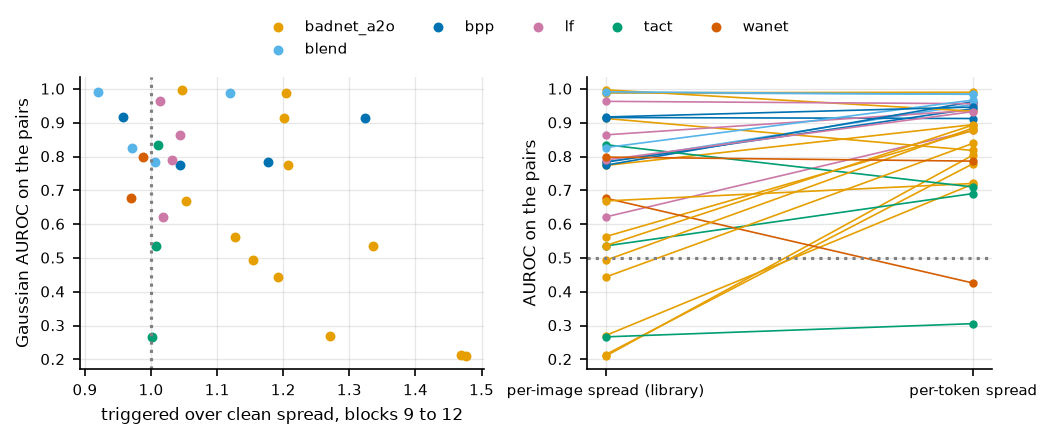

,"spread ratio, blocks 5 to 8","spread ratio, blocks 9 to 12","ordinary tokens, blocks 9 to 12",AUROC Gaussian,AUROC per-token Gaussian,clean change reached
group,,,,,,
badnet_a2o,1.029,1.228,1.227,0.589,0.846,0.603
blend,1.245,1.004,1.033,0.898,0.973,0.600
bpp,1.132,1.126,NaN,0.847,0.941,0.599
lf,1.082,1.027,NaN,0.810,0.926,0.609
tact,1.008,1.007,1.001,0.546,0.569,0.617
wanet,0.996,0.978,NaN,0.738,0.606,0.599


In [37]:
coupling_rows = []
for record in mechanics_records:
    coupling = record["coupling"]
    ratios = coupling["spread_ratio_triggered_over_clean"]
    coupling_rows.append({
        "model": record["folder"], "group": group_of(record),
        "spread ratio, blocks 5 to 8": np.mean(ratios["sample"][4:8]), "spread ratio, blocks 9 to 12": np.mean(ratios["sample"][8:]),
        "ordinary tokens, blocks 9 to 12": np.mean(ratios["ordinary_token"][8:]),
        "AUROC Gaussian": coupling["scoring"]["gaussian"]["auroc_on_pairs"],
        "AUROC per-token Gaussian": coupling["scoring"]["gaussian_per_token"]["auroc_on_pairs"],
        "clean change reached": coupling["scoring"]["gaussian"]["calibration"]["clean_change_at_rate"],
    })
coupling_frame = pd.DataFrame(coupling_rows).set_index("model")
figure, axes = plt.subplots(1, 2, figsize=(TEXT_WIDTH, 2.4), constrained_layout=True)
for name, row in coupling_frame.iterrows():
    axes[0].scatter(row["spread ratio, blocks 9 to 12"], row["AUROC Gaussian"], color=attack_color_of(row["group"]), s=14, label=row["group"])
    axes[1].plot([0, 1], [row["AUROC Gaussian"], row["AUROC per-token Gaussian"]], color=attack_color_of(row["group"]), marker="o", markersize=3, linewidth=0.8)
axes[0].axvline(1, color="0.5", linestyle=":")
axes[0].set_xlabel("triggered over clean spread, blocks 9 to 12")
axes[0].set_ylabel("Gaussian AUROC on the pairs")
axes[1].set_xticks([0, 1], ["per-image spread (library)", "per-token spread"])
axes[1].set_ylabel("AUROC on the pairs")
axes[1].axhline(0.5, color="0.5", linestyle=":")
legend_above(figure, [axes[0]], columns=5)
plt.show()
coupling_means = coupling_frame.groupby("group").mean().round(3)
coupling_means

In [38]:
display(Markdown(rf"""
Left: each model's triggered over clean spread in blocks 9 to 12 against its library Gaussian AUROC on the pairs. Right: each model's AUROC with the library Gaussian and with the per-token Gaussian. Verdict: supported, with a correction to where the coupling sits. On BadNets the spread ratio is {coupling_means.loc["badnet_a2o", "spread ratio, blocks 9 to 12"]:.2f} in blocks 9 to 12 and {coupling_means.loc["badnet_a2o", "spread ratio, blocks 5 to 8"]:.2f} in blocks 5 to 8, so the coupling is a late-block effect rather than the predicted blocks 5 to 12, and the ordinary tokens' own spread rises with it ({coupling_means.loc["badnet_a2o", "ordinary tokens, blocks 9 to 12"]:.2f}), so it is not only the trigger tokens that inflate it. Scaling the noise per token lifts the mean BadNets AUROC from {coupling_means.loc["badnet_a2o", "AUROC Gaussian"]:.3f} to {coupling_means.loc["badnet_a2o", "AUROC per-token Gaussian"]:.3f}. So part of the Gaussian's loss is a property of how the operator sets its scale and not of additive noise as such. It is separate from the all-or-nothing account, which compares the 2 operators at equal clean damage whatever their scale.
"""))


Left: each model's triggered over clean spread in blocks 9 to 12 against its library Gaussian AUROC on the pairs. Right: each model's AUROC with the library Gaussian and with the per-token Gaussian. Verdict: supported, with a correction to where the coupling sits. On BadNets the spread ratio is 1.23 in blocks 9 to 12 and 1.03 in blocks 5 to 8, so the coupling is a late-block effect rather than the predicted blocks 5 to 12, and the ordinary tokens' own spread rises with it (1.23), so it is not only the trigger tokens that inflate it. Scaling the noise per token lifts the mean BadNets AUROC from 0.589 to 0.846. So part of the Gaussian's loss is a property of how the operator sets its scale and not of additive noise as such. It is separate from the all-or-nothing account, which compares the 2 operators at equal clean damage whatever their scale.


### "The attention input is special whatever the operator"

Claim: site A wins because it is where attention reads, independently of the operator. Prediction: dropout, channel masking and noise at A beat the same operators on the stream or at the MLP input by about as much as token masking does. Measurement: step 8's contrasts.

In [39]:
display(Markdown(rf"""
Verdict: refuted for dropout and partly supported for the others. Dropout at A against dropout on the stream is {gap("vit", "dropout_attention_input_vs_stream")} on ViT and {gap("swin", "dropout_attention_input_vs_stream")} on Swin, no reliable gain, while token masking at A against token masking on the stream is {gap("vit", "token_mask_attention_input_vs_stream")}. The attention input against the MLP input does favor every operator on ViT (dropout {gap("vit", "dropout_attention_input_vs_mlp_input")}, channel masking {gap("vit", "channel_mask_attention_input_vs_mlp_input")}, Gaussian {gap("vit", "gaussian_attention_input_vs_mlp_input")}), because at the MLP input attention has already copied the trigger into other tokens and a probe there cannot hide it from the read. The site is necessary and not sufficient: it pays off in full only with token masking.
"""))


Verdict: refuted for dropout and partly supported for the others. Dropout at A against dropout on the stream is -0.018 [-0.063, +0.029] (n 56) on ViT and +0.009 [-0.038, +0.056] (n 63) on Swin, no reliable gain, while token masking at A against token masking on the stream is +0.071 [+0.038, +0.106] (n 56). The attention input against the MLP input does favor every operator on ViT (dropout +0.108 [+0.068, +0.150] (n 56), channel masking +0.133 [+0.096, +0.173] (n 36), Gaussian +0.065 [+0.004, +0.130] (n 35)), because at the MLP input attention has already copied the trigger into other tokens and a probe there cannot hide it from the read. The site is necessary and not sufficient: it pays off in full only with token masking.


### "Whole-token masking is just stronger dropout"

Claim: token masking at rate p removes as much information as dropout at some higher rate, and the 2 are the same probe at different strengths. Prediction: some dropout rate at A reaches token masking's AUROC at the same clean damage, and at matched clean damage both leave the trigger's reads in the same state.

In [40]:
display(Markdown(rf"""
Verdict: refuted. On the ladders no dropout rate at A reaches token masking's curve at any clean shift, the best dropout point reading {best[("vit", "dropout")]:.3f} on ViT against {best[("vit", "token mask")]:.3f} (step 9). At the matched rule the gap is {gap("vit", "attention_input_token_mask_vs_dropout")}. And step 10 shows the difference in kind at equal clean damage: dropout on the tokens around the trigger (ViT) or on the trigger's own tokens (Swin) breaks triggered predictions, and token masking on the same positions does not.
"""))


Verdict: refuted. On the ladders no dropout rate at A reaches token masking's curve at any clean shift, the best dropout point reading 0.929 on ViT against 0.959 (step 9). At the matched rule the gap is +0.086 [+0.058, +0.110] (n 56). And step 10 shows the difference in kind at equal clean damage: dropout on the tokens around the trigger (ViT) or on the trigger's own tokens (Swin) breaks triggered predictions, and token masking on the same positions does not.


### Masking once at the embedding, and why its sign flips against Doan et al.

Doan et al. (AAAI 2023) randomly delete image patches before the first block and flag an input whose prediction changes. Their reasoning in plain words: a patch trigger lives in a few patches, so deleting patches often deletes the trigger and the backdoored prediction flips, while a clean prediction rests on many patches and survives. That is the opposite sign from PSBD, which flags the prediction that survives. The literature memo's L18 asked whether token masking at the embedding behaves like their PatchDrop, and predicted that triggered survival rises with the number $j$ of trigger tokens left unmasked, near 0 at $j = 0$ and at least 0.9 at $j = 4$. The theory memo pointed out a confound: at the embedding no LayerNorm follows the mask, so `TokenMask`'s 1/(1-p) rescale of the survivors enters the residual stream, 3.3 times at p 0.7.

What is measured (`mechanics.py`, part `embedding`): `after_embedding` token masking with its masks recorded, at the fixed rates 0.5 and 0.7, with the library rescale and without it (`mechanics.RecordingUnscaledTokenMask`), 10 passes, triggered survival by $j$ with the share of clean images sent to the target at the same $j$ beside it.

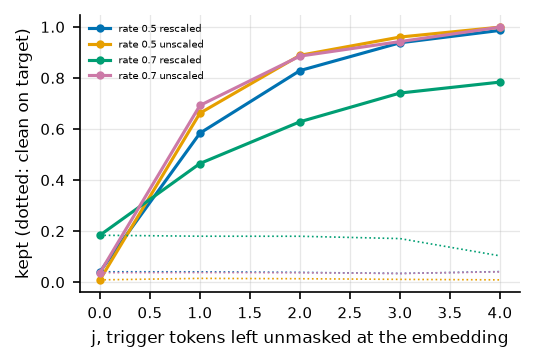

triggered kept     n  clean on target share
setting           j                                             
rate_0.5_rescaled 0           0.042  1383                  0.042
                  1           0.585  5592                  0.042
                  2           0.830  8509                  0.039
                  3           0.939  6051                  0.035
                  4           0.987  1485                  0.042
rate_0.5_unscaled 0           0.010  1383                  0.010
                  1           0.663  5592                  0.016
                  2           0.890  8509                  0.015
                  3           0.961  6051                  0.012
                  4           1.000  1485                  0.010
rate_0.7_rescaled 0           0.185  5477                  0.185
                  1           0.466  9106                  0.181
                  2           0.629  6333                  0.181
                  3           0.742  1960                  0.172
                  4           0.785   144                  0.104
rate_0.7_unscaled 0           0.038  5477                  0.038
                  1           0.693  9106                  0.039
                  2           0.887  6333                  0.038
                  3           0.943  1960                  0.035
                  4           1.000   144                  0.042

In [41]:
embedding_rows = []
for record in mechanics_records:
    if group_of(record) != "badnet_a2o" or record["trigger_tokens"] != 4:
        continue
    for key, block in record["embedding"].items():
        for j, (kept, total) in block["triggered_by_surviving_trigger_tokens"].items():
            on_target = block["clean_on_target_by_surviving_trigger_tokens"].get(j, [0, 1])
            embedding_rows.append({"setting": key, "j": int(j), "kept": kept, "n": total, "clean on target": on_target[0], "clean n": on_target[1]})
embedding = pd.DataFrame(embedding_rows).groupby(["setting", "j"]).sum()
embedding["triggered kept"] = embedding["kept"] / embedding["n"]
embedding["clean on target share"] = embedding["clean on target"] / embedding["clean n"]
figure, axis = plt.subplots(figsize=(TEXT_WIDTH / 2, 2.3), constrained_layout=True)
for setting, rows in embedding.groupby(level="setting"):
    rows = rows.droplevel("setting")
    line = axis.plot(rows.index, rows["triggered kept"], marker="o", markersize=3, label=setting.replace("_", " "))[0]
    axis.plot(rows.index, rows["clean on target share"], linestyle=":", color=line.get_color(), linewidth=0.8)
axis.set_xlabel("j, trigger tokens left unmasked at the embedding")
axis.set_ylabel("kept (dotted: clean on target)")
axis.legend(fontsize=5)
plt.show()
embedding[["triggered kept", "n", "clean on target share"]].round(3)

In [42]:
display(Markdown(rf"""
Solid lines: triggered survival at each $j$, over the 4-token BadNets ViT models. Dotted lines: the share of clean images the same masks send to the target, the floor a collapsing model produces. Verdict: L18's prediction holds once the confound is removed. Without the rescale, survival is {embedding.loc[("rate_0.7_unscaled", 0), "triggered kept"]:.3f} at $j = 0$ and rises to {embedding.loc[("rate_0.7_unscaled", 2), "triggered kept"]:.3f} at $j = 2$ at rate 0.7, with almost no clean image sent to the target. With the library rescale at 0.7 the model collapses onto the target ({embedding.loc[("rate_0.7_rescaled", 0), "clean on target share"]:.3f} of clean images at $j = 0$), which makes triggered survival at $j = 0$ read {embedding.loc[("rate_0.7_rescaled", 0), "triggered kept"]:.3f} for a reason unrelated to the trigger. At the embedding a masked trigger token is gone for the whole network, so the triggered prediction depends on which trigger tokens survive the single draw, and it breaks whenever none do. That is Doan et al.'s regime, where instability flags the trigger. At site A the same token is gone for 1 read only and its stream entry survives. The prediction then breaks only when enough late reads are lost, which is rare, so stability flags the trigger. Both signs are correct for their sites.
"""))


Solid lines: triggered survival at each $j$, over the 4-token BadNets ViT models. Dotted lines: the share of clean images the same masks send to the target, the floor a collapsing model produces. Verdict: L18's prediction holds once the confound is removed. Without the rescale, survival is 0.038 at $j = 0$ and rises to 0.887 at $j = 2$ at rate 0.7, with almost no clean image sent to the target. With the library rescale at 0.7 the model collapses onto the target (0.185 of clean images at $j = 0$), which makes triggered survival at $j = 0$ read 0.185 for a reason unrelated to the trigger. At the embedding a masked trigger token is gone for the whole network, so the triggered prediction depends on which trigger tokens survive the single draw, and it breaks whenever none do. That is Doan et al.'s regime, where instability flags the trigger. At site A the same token is gone for 1 read only and its stream entry survives. The prediction then breaks only when enough late reads are lost, which is rare, so stability flags the trigger. Both signs are correct for their sites.


### "A constant masked token is an off-manifold artifact" (L22) and "PSU measures curvature" (L2)

L22 predicted that `token_substitute`, which removes a token's content and stays on the data manifold, reads within 0.02 of token masking if the constant is a nuisance. L2 predicted that Rademacher noise, which has the Gaussian's covariance, matches it within 0.01 at each site if PSU estimates curvature. Neither sweep is cached, so both are read on the causal grid of step 10, at matched clean damage, by triggered survival.

In [43]:
cell = grid_cell
alternatives = pd.DataFrame([
    {"architecture": ARCHITECTURE_NAMES[a], "comparison": label,
     "a kept": cell(a, site_a, op_a), "b kept": cell(a, site_b, op_b),
     "a rate": cell(a, site_a, op_a, "rate"), "b rate": cell(a, site_b, op_b, "rate")}
    for a in ARCHITECTURES
    for label, site_a, op_a, site_b, op_b in (
        ("token mask minus substitute, A", "attention_input", "token_mask", "attention_input", "token_substitute"),
        ("Gaussian minus Rademacher, A", "attention_input", "gaussian", "attention_input", "rademacher"),
        ("Gaussian minus Rademacher, after LN 2", "mlp_input_after_norm", "gaussian", "mlp_input_after_norm", "rademacher"),
    )
])
alternatives["a minus b"] = alternatives["a kept"] - alternatives["b kept"]
alternatives_text = " ".join(
    f"On {row['architecture']}, {row['comparison']}: {row['a kept']:.3f} against {row['b kept']:.3f}."
    for _, row in alternatives.iterrows()
) + (
    " L2's prediction holds in the form it can take here: Rademacher and Gaussian noise leave the same share of triggered predictions within a few points at each site, "
    "which is what equal covariance predicts under any account, so it does not single out curvature. L22's prediction, substitution within 0.02 of token masking, "
    "holds on ViT at equal clean damage and fails on Swin, where substitution keeps fewer triggered predictions."
)
alternatives.set_index(["architecture", "comparison"]).round(3)

a kept  b kept  a rate  \
architecture comparison                                                      
ViT-B/16     token mask minus substitute, A          0.912   0.915   0.374   
             Gaussian minus Rademacher, A            0.520   0.512   0.722   
             Gaussian minus Rademacher, after LN 2   0.947   0.945   1.380   
Swin-S       token mask minus substitute, A          0.997   0.862   0.381   
             Gaussian minus Rademacher, A            0.996   0.997   1.069   
             Gaussian minus Rademacher, after LN 2   0.923   0.918   0.977   

                                                    b rate  a minus b  
architecture comparison                                                
ViT-B/16     token mask minus substitute, A          0.579     -0.003  
             Gaussian minus Rademacher, A            0.739      0.008  
             Gaussian minus Rademacher, after LN 2   1.405      0.001  
Swin-S       token mask minus substitute, A          0.523      0.134  
             Gaussian minus Rademacher, A            1.036     -0.001  
             Gaussian minus Rademacher, after LN 2   0.980      0.006

In [44]:
display(Markdown(rf"""
The table gives triggered survival with each probe on all tokens at the rate that changes 60% of clean predictions. {alternatives_text}
"""))


The table gives triggered survival with each probe on all tokens at the rate that changes 60% of clean predictions. On ViT-B/16, token mask minus substitute, A: 0.912 against 0.915. On ViT-B/16, Gaussian minus Rademacher, A: 0.520 against 0.512. On ViT-B/16, Gaussian minus Rademacher, after LN 2: 0.947 against 0.945. On Swin-S, token mask minus substitute, A: 0.997 against 0.862. On Swin-S, Gaussian minus Rademacher, A: 0.996 against 0.997. On Swin-S, Gaussian minus Rademacher, after LN 2: 0.923 against 0.918. L2's prediction holds in the form it can take here: Rademacher and Gaussian noise leave the same share of triggered predictions within a few points at each site, which is what equal covariance predicts under any account, so it does not single out curvature. L22's prediction, substitution within 0.02 of token masking, holds on ViT at equal clean damage and fails on Swin, where substitution keeps fewer triggered predictions.


## Summary. Every placement on 1 plane

The last figure places every cached placement on the plane of the 2 quantities that PSU turns into AUROC, at the matched rule: the share of triggered predictions it changes (x axis, lower is better) and the resulting AUROC (y axis). Every placement changes about 60% of clean predictions there, so the x axis is the whole story of selectivity. Color is the operator and marker the site. The table after it states, for each placement family, why it wins or loses, with the step that measured it.

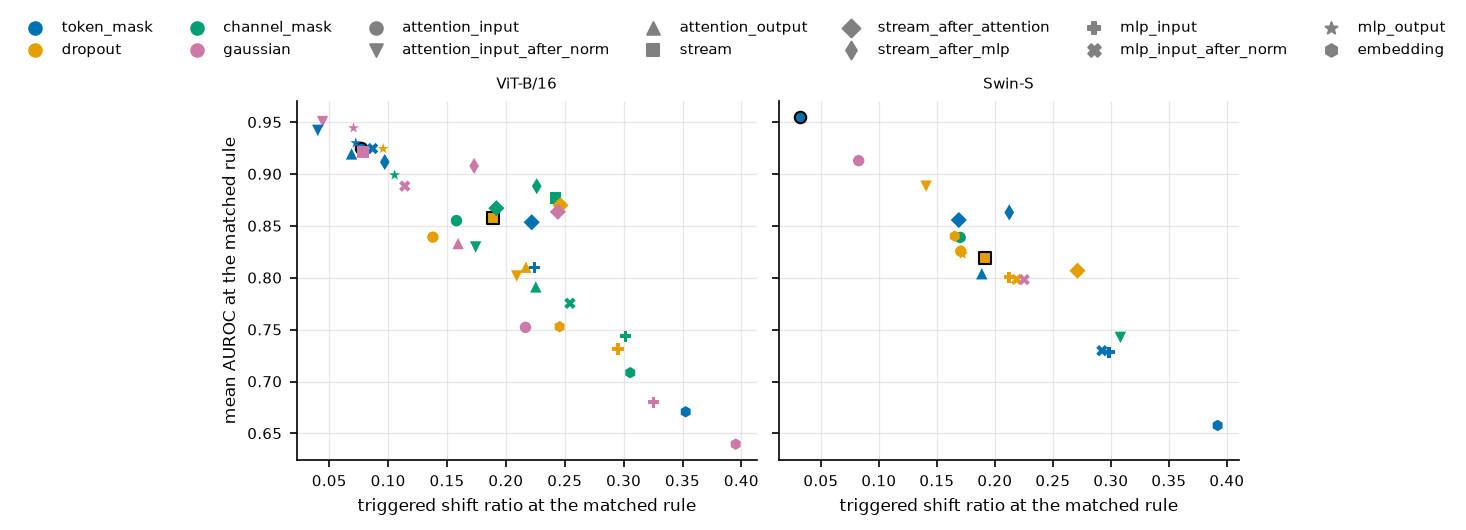

models  \
architecture placement                                          
Swin-S       attention_input__token_mask                   65   
ViT-B/16     attention_input_after_norm__gaussian          34   
             mlp_output__gaussian                          36   
             attention_input_after_norm__token_mask        36   
             mlp_output__token_mask                        36   
             attention_input__token_mask                   56   
             mlp_input_after_norm__token_mask              36   
             mlp_output__dropout                           36   
             stream__gaussian                              34   
             attention_output__token_mask                  56   
Swin-S       attention_input__gaussian                     63   
ViT-B/16     stream_after_mlp__token_mask                  36   
             stream_after_mlp__gaussian                    36   
             mlp_output__channel_mask                      36   
             mlp_input_after_norm__gaussian                56   
Swin-S       attention_input_after_norm__dropout           63   
ViT-B/16     stream_after_mlp__channel_mask                36   
             stream__channel_mask                          36   
             stream_after_attention__dropout               56   
             stream_after_attention__channel_mask          36   
             stream_after_attention__gaussian              36   
Swin-S       stream_after_mlp__token_mask                  16   
ViT-B/16     stream__dropout                               56   
Swin-S       stream_after_attention__token_mask            63   
ViT-B/16     attention_input__channel_mask                 56   
             stream_after_attention__token_mask            56   
Swin-S       embedding__dropout                            63   
ViT-B/16     attention_input__dropout                      56   
Swin-S       attention_input__channel_mask                 63   
ViT-B/16     attention_output__gaussian                    56   
             attention_input_after_norm__channel_mask      36   
Swin-S       attention_input__dropout                      63   
             mlp_output__dropout                           30   
             stream__dropout                               65   
ViT-B/16     attention_output__dropout                     56   
             mlp_input__token_mask                         56   
Swin-S       stream_after_attention__dropout               63   
             attention_output__token_mask                  65   
ViT-B/16     attention_input_after_norm__dropout           56   
Swin-S       mlp_input__dropout                            63   
             mlp_input_after_norm__dropout                 32   
             mlp_input_after_norm__gaussian                63   
ViT-B/16     attention_output__channel_mask                56   
             mlp_input_after_norm__channel_mask            36   
             embedding__dropout                            56   
             attention_input__gaussian                     56   
             mlp_input__channel_mask                       36   
Swin-S       attention_input_after_norm__channel_mask      16   
ViT-B/16     mlp_input__dropout                            56   
Swin-S       mlp_input_after_norm__token_mask              16   
             mlp_input__token_mask                         63   
ViT-B/16     embedding__channel_mask                       36   
             mlp_input__gaussian                           35   
             embedding__token_mask                         36   
Swin-S       embedding__token_mask                         26   
ViT-B/16     embedding__gaussian                           36   

                                                       triggered shift  \
architecture placement                                                   
Swin-S       attention_input__token_mask                         0.032   
ViT-B/16     attention_input_after_norm__gaussian             

In [45]:
OPERATOR_COLORS = {"token_mask": "#0072B2", "dropout": "#E69F00", "channel_mask": "#009E73", "gaussian": "#CC79A7"}
SITE_MARKERS = {"attention_input": "o", "attention_input_after_norm": "v", "attention_output": "^", "stream": "s",
                "stream_after_attention": "D", "stream_after_mlp": "d", "mlp_input": "P", "mlp_input_after_norm": "X",
                "mlp_output": "*", "embedding": "h"}
figure, axes = plt.subplots(1, 2, figsize=(TEXT_WIDTH, 3.0), sharey=True, constrained_layout=True)
plane_rows = []
for axis, architecture in zip(axes, ARCHITECTURES):
    for key, locality_means in cache[architecture]["placements"].items():
        site, operator = key.split("__")
        reading = locality_means["all"]["matched"]
        if reading["n"] < 10 or operator not in OPERATOR_COLORS or reading["shift_backdoor"] is None:
            continue
        axis.scatter(reading["shift_backdoor"], reading["auroc"], color=OPERATOR_COLORS[operator], marker=SITE_MARKERS.get(site, "o"), s=30,
                     edgecolors="black" if key == TM or key == RD else "none")
        plane_rows.append({"architecture": ARCHITECTURE_NAMES[architecture], "placement": key, "models": reading["n"],
                           "triggered shift": reading["shift_backdoor"], "clean shift": reading["shift_clean"], "AUROC": reading["auroc"]})
    axis.set_title(ARCHITECTURE_NAMES[architecture], fontsize=7)
    axis.set_xlabel("triggered shift ratio at the matched rule")
axes[0].set_ylabel("mean AUROC at the matched rule")
for operator, color in OPERATOR_COLORS.items():
    axes[0].scatter([], [], color=color, label=operator)
for site, marker in SITE_MARKERS.items():
    axes[0].scatter([], [], color="0.5", marker=marker, label=site)
legend_above(figure, [axes[0]], columns=7)
plt.show()
plane = pd.DataFrame(plane_rows).set_index(["architecture", "placement"]).sort_values("AUROC", ascending=False)
plane.round(3)

In [46]:
display(Markdown(rf"""
The placements with a black edge are PSBD-TM (circle, blue) and PSBD-RD (square, orange). Every placement lies close to 1 falling line: at the same clean damage the fewer triggered predictions a probe changes, the higher its AUROC. PSBD-TM is the point furthest to the left on both architectures.

Rows whose "why" rests on a hypothesis say so.

| placement family | verdict | why | where measured |
|---|---|---|---|
| token mask at the attention input (A, PSBD-TM) | wins | measured: a masked token keeps its stream entry, the trigger is read over several late blocks, masking the other tokens outright barely disturbs the trigger's route (ViT) and masking the trigger's tokens in some blocks does little harm (Swin). Hypothesis: the masked sink draws the class token off clean content | steps 3 to 5, 10, 11 |
| token mask at the attention output (C) | ties on ViT, loses on Swin | same stream-sparing mechanism 1 step later, but the class token in this block is untouched (ViT) and Swin's windowed attention has already spread the trigger | step 8 |
| token mask after LN 1 (B) | close, slightly worse | the norm neither helps nor hurts masking | step 12 |
| token mask on the stream or at the embedding | loses | a masked stream entry is gone for every later block, so the trigger itself is removed and the triggered prediction breaks like a clean one, Doan et al.'s regime | steps 8, 12 |
| token mask at the MLP input (E) | loses | attention has already copied the trigger into other tokens, and masking there erases the tokens' own rewritten content | steps 8, 11 |
| dropout at A or on the stream (PSBD-RD) | loses | measured: at equal clean damage it changes more triggered predictions, partial corruption of the other tokens (ViT) or of the trigger's tokens (Swin) breaks them, and on the stream it erodes the trigger's stored signal | steps 6, 9, 10, 11 |
| channel mask at A | loses | measured: like dropout, partial removal from every token breaks triggered predictions where whole-token masking does not | steps 8, 10 |
| Gaussian or Rademacher noise at A | loses most | measured: on ViT it breaks triggered predictions through the tokens that do not carry the trigger, and per-token noise scaling recovers much of the loss on BadNets (the coupling test) | steps 10, 12 |

The account holds on both architectures. On ViT the trigger's evidence reaches the class token through attention in blocks 5 to 12, on Swin through windowed attention in stage 3 and then through many tokens to the pooled head, and on both its own stream entry is what token masking at the attention input spares. What this notebook does not settle is recorded in `experiments/why_token_masking_works/README.md` under Limits, and the runs still missing from the records are listed there under the run status.
"""))


The placements with a black edge are PSBD-TM (circle, blue) and PSBD-RD (square, orange). Every placement lies close to 1 falling line: at the same clean damage the fewer triggered predictions a probe changes, the higher its AUROC. PSBD-TM is the point furthest to the left on both architectures.

Rows whose "why" rests on a hypothesis say so.

| placement family | verdict | why | where measured |
|---|---|---|---|
| token mask at the attention input (A, PSBD-TM) | wins | measured: a masked token keeps its stream entry, the trigger is read over several late blocks, masking the other tokens outright barely disturbs the trigger's route (ViT) and masking the trigger's tokens in some blocks does little harm (Swin). Hypothesis: the masked sink draws the class token off clean content | steps 3 to 5, 10, 11 |
| token mask at the attention output (C) | ties on ViT, loses on Swin | same stream-sparing mechanism 1 step later, but the class token in this block is untouched (ViT) and Swin's windowed attention has already spread the trigger | step 8 |
| token mask after LN 1 (B) | close, slightly worse | the norm neither helps nor hurts masking | step 12 |
| token mask on the stream or at the embedding | loses | a masked stream entry is gone for every later block, so the trigger itself is removed and the triggered prediction breaks like a clean one, Doan et al.'s regime | steps 8, 12 |
| token mask at the MLP input (E) | loses | attention has already copied the trigger into other tokens, and masking there erases the tokens' own rewritten content | steps 8, 11 |
| dropout at A or on the stream (PSBD-RD) | loses | measured: at equal clean damage it changes more triggered predictions, partial corruption of the other tokens (ViT) or of the trigger's tokens (Swin) breaks them, and on the stream it erodes the trigger's stored signal | steps 6, 9, 10, 11 |
| channel mask at A | loses | measured: like dropout, partial removal from every token breaks triggered predictions where whole-token masking does not | steps 8, 10 |
| Gaussian or Rademacher noise at A | loses most | measured: on ViT it breaks triggered predictions through the tokens that do not carry the trigger, and per-token noise scaling recovers much of the loss on BadNets (the coupling test) | steps 10, 12 |

The account holds on both architectures. On ViT the trigger's evidence reaches the class token through attention in blocks 5 to 12, on Swin through windowed attention in stage 3 and then through many tokens to the pooled head, and on both its own stream entry is what token masking at the attention input spares. What this notebook does not settle is recorded in `experiments/why_token_masking_works/README.md` under Limits, and the runs still missing from the records are listed there under the run status.
